# NB13 --- GraphCodeBERT avec le graphe réel : validation du pipeline avant le passage à l'échelle (RQ2)
### GraphCodeBERT (Graph-Guided): Pipeline Validation Before Scaling Up (RQ2)

**Où on en est.** NB12 a montré que GraphCodeBERT *naïf* (poids GraphCodeBERT,
pipeline strictement identique à CodeBERT, aucun graphe construit) bat CodeBERT
de façon quasi systématique (12/12 problèmes sur le verdict). C'est un signal
résiduel du pré-entraînement structure-aware --- mais ce n'est **pas** un test du
mécanisme de graphe de GraphCodeBERT, puisqu'aucun graphe n'est jamais fourni au
modèle.

**Ce que ce notebook fait.** `embedding.py` sait maintenant construire le vrai
graphe de flux de données --- tree-sitter + `DFG.py` officiel (vendored sous
`src/parser/`, code de microsoft/CodeBERT/GraphCodeBERT, licence MIT) --- et le
fournir au modèle via son mécanisme d'attention guidée par le graphe (méthode
`graphcodebert_ast`). **S1** valide seulement que le pipeline fonctionne
correctement sur un petit corpus pilote (~20 soumissions, p02659) : le graphe
s'extrait-il sans erreur, l'embedding a-t-il la bonne forme, et diffère-t-il
substantiellement de la version naïve ? (Réponse : oui aux trois --- pilote
concluant, voir sortie de S1.)

**Deux écarts délibérés par rapport au code officiel** --- découverts en le
faisant tourner sur le vrai checkpoint, pas des choix de conception a priori :
1. Le checkpoint `microsoft/graphcodebert-base` ne contient **aucun poids de
   pooler** (vérifié directement dans son state dict : seulement `roberta.*`
   et `lm_head.*`). Le `pooler_output` que le code officiel lit en sortie
   (`forward()[1]`) suppose un fine-tuning préalable qui l'entraîne ; sans
   fine-tuning, ce serait un vecteur partiellement aléatoire. On lit à la
   place le token CLS de `last_hidden_state`, comme le fait déjà
   `embed_codebert()` --- pour que la comparaison naïf/graphe isole l'effet du
   graphe plutôt que d'ajouter un second changement.
2. L'API de masquage d'attention de `transformers` a changé depuis la
   publication du code officiel (2021) : un masque 2D personnalisé doit
   maintenant être passé en 4D pour être accepté tel quel plutôt que
   retraité (et cassé) par les nouvelles routines de masquage.

**Étape suivante (S2 et après).** Ce même notebook applique aux quatre
méthodes l'analyse déjà validée en NB11/NB12 (criblage k-NN, heatmaps de
confusion, UMAP, t-SNE) --- avec, dès le criblage (S3),
**Δ(GraphCodeBERT_AST − GraphCodeBERT)** mise en avant : elle isole l'effet du
seul mécanisme de graphe, à architecture et pré-entraînement identiques,
exactement comme NB12 isolait déjà Δ(GraphCodeBERT naïf − CodeBERT). S3 à S7
nécessitent le corpus complet (12 problèmes, en cours de génération au moment
d'écrire ces lignes) --- elles se dégradent proprement si `graphcodebert_ast`
n'est pas encore disponible, comme NB12 le faisait déjà pour un corpus
manquant.

---

**Where we stand.** NB12 showed that *naive* GraphCodeBERT (GraphCodeBERT's
weights, a pipeline strictly identical to CodeBERT's, no graph ever built)
beats CodeBERT almost systematically (12/12 problems on verdict). This is a
residual signal from structure-aware pre-training --- but it is **not** a test
of GraphCodeBERT's graph mechanism, since no graph is ever given to the model.

**What this notebook does.** `embedding.py` can now build the actual data-flow
graph --- tree-sitter + the official `DFG.py` (vendored under `src/parser/`,
code from microsoft/CodeBERT/GraphCodeBERT, MIT license) --- and feed it to the
model through its graph-guided attention mechanism (method `graphcodebert_ast`).
**S1** only validates that the pipeline works correctly on a small pilot corpus
(~20 submissions, p02659): does the graph extract cleanly, does the resulting
embedding have the right shape, and does it differ substantially from the naive
version? (Answer: yes to all three --- pilot successful, see S1's output.)

**Two deliberate deviations from the official code** --- found by actually
running it against the real checkpoint, not a priori design choices:
1. The `microsoft/graphcodebert-base` checkpoint ships **no pooler weights at
   all** (verified directly against its state dict: only `roberta.*` and
   `lm_head.*`). The official code's output, `pooler_output`
   (`forward()[1]`), assumes prior fine-tuning that trains it; without
   fine-tuning it would be a partly random vector. We read the CLS position
   of `last_hidden_state` instead, matching what `embed_codebert()` already
   does --- so the naive/graph-guided comparison isolates the effect of the
   graph rather than also changing the readout.
2. `transformers`'s attention-masking API has changed since the official code
   was published (2021): a custom 2D mask now has to be passed as 4D to be
   accepted as-is, rather than being reprocessed (and broken) by the newer
   masking routines.

**Next step (S2 onward).** This same notebook applies to all four methods the
analysis already validated in NB11/NB12 (k-NN screening, confusion heatmaps,
UMAP, t-SNE) --- with, starting at the screening step (S3),
**Δ(GraphCodeBERT_AST − GraphCodeBERT)** front and center: it isolates the
effect of the graph mechanism alone, holding architecture and pre-training
fixed, exactly as NB12 already isolated Δ(naive GraphCodeBERT − CodeBERT). S3
through S7 need the full corpus (12 problems, still being generated as this is
written) --- they degrade cleanly if `graphcodebert_ast` isn't available yet,
the same way NB12 already did for a missing corpus.

In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EMBEDDINGS_DIR: {EMBEDDINGS_DIR}  (exists={EMBEDDINGS_DIR.exists()})")

STATUS_COLORS = {
    'AC':  '#2ecc71',
    'WA':  '#e74c3c',
    'TLE': '#e67e22',
    'CE':  '#9b59b6',
    'RE':  '#3498db',
}
DIFF_COLORS = {'B': '#1abc9c', 'C': '#3498db', 'D': '#e74c3c', 'E': '#9b59b6'}
GROUP_COLORS = {
    'G1': '#c0392b', 'G2': '#e67e22', 'G3': '#f1c40f',
    'G4': '#2ecc71', 'G5': '#3498db', 'G6': '#9b59b6',
}
STATUSES_ORDER = ['AC', 'WA', 'TLE', 'CE', 'RE']
DIFFS_ORDER    = ['B', 'C', 'D', 'E']
GROUPS_ORDER   = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']

# Une couleur par méthode, cohérente sur tout le notebook --- rouge pour
# graphcodebert_ast, seule méthode nouvelle ici, pour qu'elle ressorte.
METHOD_COLORS = {
    'tfidf_python_multi12':             '#7f8c8d',
    'codebert_python_multi12':          '#2980b9',
    'graphcodebert_python_multi12':     '#27ae60',
    'graphcodebert_ast_python_multi12': '#e74c3c',
}

PROJECT_ROOT  : /Users/raphael/OJS-submission-analytics
EMBEDDINGS_DIR: /Users/raphael/OJS-submission-analytics/data/processed/embeddings  (exists=True)


## S0 --- Génération du corpus pilote
### S0 --- Generating the Pilot Corpus

Un seul problème (p02659 --- déjà utilisé comme référence en NB11/NB12), quota
réduit (5/case au lieu de 500) pour rester à l'échelle d'un pilote : ~20
soumissions selon le nombre de verdicts effectifs pour ce problème en Python.
Même tirage stratifié et même seed (42) que partout ailleurs dans le pipeline
--- seul le quota change.

```bash
python src/embedding.py graphcodebert_ast mps "Python" p02659 5
```

(remplacer `mps` par `cpu` ou `cuda` selon la machine --- voir `python
src/embedding.py help`)

---

A single problem (p02659 --- already used as a reference in NB11/NB12), a
reduced quota (5/cell instead of 500) to stay pilot-scale: ~20 submissions
depending on how many verdicts actually occur for this problem in Python.
Same stratified draw and same seed (42) as everywhere else in the pipeline
--- only the quota changes.

```bash
python src/embedding.py graphcodebert_ast mps "Python" p02659 5
```

(swap `mps` for `cpu` or `cuda` depending on the machine --- see `python
src/embedding.py help`)

## S1 --- Validation : le pipeline tourne-t-il correctement sur le pilote ?
### S1 --- Validation: Does the Pipeline Run Correctly on the Pilot?

Pas encore une analyse RQ2 --- juste la question préalable qui la rend possible.
On vérifie que les embeddings chargés sont bien formés (forme, dtype, pas de
NaN ni de vecteur nul), on regarde la répartition par verdict, et on calcule un
premier indicateur qualitatif (similarité cosinus intra- vs inter-verdict) ---
purement indicatif : avec 5 soumissions/case, il n'y a pas assez de données pour
une lecture statistique fiable (contrairement au lift k-NN utilisé en NB10--NB12
sur le corpus complet, 500/case).

---

Not an RQ2 analysis yet --- just the prerequisite question that makes one
possible. We check that the loaded embeddings are well-formed (shape, dtype, no
NaN or zero vector), look at the verdict breakdown, and compute one early
qualitative indicator (intra- vs inter-verdict cosine similarity) --- purely
indicative: with 5 submissions/cell there isn't enough data for a reliable
statistical read (unlike the k-NN lift used in NB10--NB12 on the full corpus,
500/cell).

In [2]:
PILOT_TAG = "graphcodebert_ast_python_p02659_n5"
emb_path  = EMBEDDINGS_DIR / f"embeddings_{PILOT_TAG}.npy"
meta_path = EMBEDDINGS_DIR / f"metadata_{PILOT_TAG}.csv"

if not emb_path.exists() or not meta_path.exists():
    print(f"Corpus pilote introuvable : {PILOT_TAG}")
    print("Lancez d'abord la commande de la cellule S0 ci-dessus, puis ré-exécutez cette cellule.")
else:
    emb  = np.load(emb_path)
    meta = pl.read_csv(meta_path)

    print(f"embeddings : {emb.shape}  dtype={emb.dtype}")
    print(f"metadata   : {meta.height} lignes")
    assert emb.shape[0] == meta.height, "désalignement embeddings / métadonnées"
    assert emb.shape[1] == 768, f"dimension inattendue : {emb.shape[1]}"
    assert not np.isnan(emb).any(), "NaN détectés dans les embeddings"
    assert not np.all(emb == 0), "embeddings entièrement nuls"
    print("Formes et valeurs : OK (pas de NaN, pas de vecteur nul, dimension 768 attendue)")

    print("\nRépartition par verdict :")
    print(meta.group_by("status_code").len().sort("status_code"))

    # Similarité cosinus intra- vs inter-verdict --- indicatif seulement (voir S1).
    norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    sim  = norm @ norm.T
    statuses = meta["status_code"].to_numpy()
    n = len(statuses)
    intra, inter = [], []
    for i in range(n):
        for j in range(i + 1, n):
            (intra if statuses[i] == statuses[j] else inter).append(sim[i, j])

    print(f"\nSimilarité cosinus moyenne --- même verdict      : {np.mean(intra):.4f}  (n={len(intra)} paires)")
    print(f"Similarité cosinus moyenne --- verdict différent : {np.mean(inter):.4f}  (n={len(inter)} paires)")
    print("\nPipeline graphcodebert_ast validé sur ce pilote. Prochaine étape si ces chiffres")
    print("sont cohérents : le corpus complet (12 problèmes, comme NB11/NB12) --- voir README.")

embeddings : (20, 768)  dtype=float32
metadata   : 20 lignes
Formes et valeurs : OK (pas de NaN, pas de vecteur nul, dimension 768 attendue)

Répartition par verdict :
shape: (4, 2)
┌─────────────┬─────┐
│ status_code ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ AC          ┆ 5   │
│ RE          ┆ 5   │
│ TLE         ┆ 5   │
│ WA          ┆ 5   │
└─────────────┴─────┘

Similarité cosinus moyenne --- même verdict      : 0.8407  (n=40 paires)
Similarité cosinus moyenne --- verdict différent : 0.8354  (n=150 paires)

Pipeline graphcodebert_ast validé sur ce pilote. Prochaine étape si ces chiffres
sont cohérents : le corpus complet (12 problèmes, comme NB11/NB12) --- voir README.


## S2 --- Chargement des 4 corpus
### S2 --- Loading the 4 Corpora

`tfidf`, `codebert` et `graphcodebert` (naïf) sont ceux de NB11/NB12, réutilisés
tels quels --- même 12 problèmes, même filtre Python, mêmes 21 773 soumissions.
`graphcodebert_ast` est nouveau (voir S0) : mêmes soumissions en principe (même
tirage stratifié, même seed 42), sauf si la génération n'est pas encore
terminée, auquel cas ce chargement l'ignore proprement et les sections
suivantes tournent avec les méthodes disponibles --- il suffit de relancer
cette cellule une fois la génération finie.

---

`tfidf`, `codebert`, and `graphcodebert` (naive) are NB11/NB12's, reused as-is
--- same 12 problems, same Python filter, same 21,773 submissions.
`graphcodebert_ast` is new (see S0): same submissions in principle (same
stratified draw, same seed 42), unless generation isn't finished yet, in which
case this loading step skips it cleanly and the following sections run with
whatever methods are available --- just re-run this cell once generation is
done.

In [3]:
METHODS_4 = ["tfidf_python_multi12", "codebert_python_multi12",
             "graphcodebert_python_multi12", "graphcodebert_ast_python_multi12"]

embeddings_4 = {}
df_meta_4    = {}

for m in METHODS_4:
    emb_path  = EMBEDDINGS_DIR / f"embeddings_{m}.npy"
    meta_path = EMBEDDINGS_DIR / f"metadata_{m}.csv"
    if not emb_path.exists():
        print(f"[MANQUANT] {m}  (pas encore généré --- voir S0 pour graphcodebert_ast)")
        continue
    embeddings_4[m] = np.load(emb_path)
    df_meta_4[m]    = pl.read_csv(meta_path)
    meta = df_meta_4[m]
    print(f"{m:34s} : {embeddings_4[m].shape}  |  {meta.height:,} soumissions")

methods_present = [m for m in METHODS_4 if m in embeddings_4]
print(f"\nMéthodes chargées : {methods_present}")
if "graphcodebert_ast_python_multi12" not in methods_present:
    print("graphcodebert_ast pas encore prêt --- relancer cette cellule une fois la")
    print("génération terminée pour l'inclure dans les sections suivantes.")

tfidf_python_multi12               : (21773, 10000)  |  21,773 soumissions
codebert_python_multi12            : (21773, 768)  |  21,773 soumissions
graphcodebert_python_multi12       : (21773, 768)  |  21,773 soumissions
graphcodebert_ast_python_multi12   : (21773, 768)  |  21,773 soumissions

Méthodes chargées : ['tfidf_python_multi12', 'codebert_python_multi12', 'graphcodebert_python_multi12', 'graphcodebert_ast_python_multi12']


## S3 --- Criblage quantitatif : lift k-NN
### S3 --- Quantitative Screening: k-NN Lift

Même protocole que NB11 S2 / NB12 S2 : pour chaque problème, on restreint
l'espace à ses seules soumissions et on recalcule le k-NN localement, pour
`status_code` et `proficiency_group`.

La comparaison centrale pour ce notebook n'est ni Δ(CodeBERT − TF-IDF) ni
Δ(GraphCodeBERT − TF-IDF), mais **Δ(GraphCodeBERT_AST − GraphCodeBERT)** : les
deux partagent exactement le même checkpoint et le même pré-entraînement, et ne
diffèrent que par un seul facteur --- le graphe de flux de données est-il
réellement construit et fourni au modèle, ou non. C'est la comparaison la plus
proche d'un test contrôlé du mécanisme de graphe lui-même, dans la lignée de
Δ(GraphCodeBERT naïf − CodeBERT) déjà mis en avant en NB12. TF-IDF et CodeBERT
restent affichés pour le contexte, mais ne sont pas au centre de la question
posée ici.

---

Same protocol as NB11 S2 / NB12 S2: for each problem, the space is restricted
to its own submissions and k-NN is recomputed locally, for `status_code` and
`proficiency_group`.

The central comparison for this notebook is neither Δ(CodeBERT − TF-IDF) nor
Δ(GraphCodeBERT − TF-IDF), but **Δ(GraphCodeBERT_AST − GraphCodeBERT)**: the
two share the exact same checkpoint and pre-training, differing in only one
factor --- whether the data-flow graph is actually built and given to the
model, or not. This is the closest thing to a controlled test of the graph
mechanism itself, in the spirit of Δ(naive GraphCodeBERT − CodeBERT) already
highlighted in NB12. TF-IDF and CodeBERT are still shown for context, but
aren't the focus of this notebook's question.

In [4]:
from sklearn.neighbors import NearestNeighbors

K = 10
TARGET_LABELS = ['status_code', 'proficiency_group']
LABEL_NAMES   = {'status_code': 'verdict', 'proficiency_group': 'groupe'}

s3_rows = []
for m in methods_present:
    emb, meta = embeddings_4[m], df_meta_4[m]
    problems = meta.select(['problem_id', 'difficulty']).unique().sort('problem_id')
    print(f"\n{m} --- criblage sur {problems.height} problèmes...")

    for row in problems.iter_rows(named=True):
        pid, diff = row['problem_id'], row['difficulty']
        idx_pid = np.where((meta['problem_id'] == pid).to_numpy())[0]
        if len(idx_pid) < K + 1:
            continue

        sub_emb = emb[idx_pid]
        k_eff = min(K, len(idx_pid) - 1)
        nbrs = NearestNeighbors(n_neighbors=k_eff + 1, metric='cosine', algorithm='brute', n_jobs=-1)
        nbrs.fit(sub_emb)
        _, nn_idx = nbrs.kneighbors(sub_emb)

        for label in TARGET_LABELS:
            labels_arr = meta[label].to_numpy()[idx_pid]
            cons = float(np.mean([
                np.sum(labels_arr[nn_idx[i, 1:]] == labels_arr[i]) / k_eff
                for i in range(len(labels_arr))
            ]))
            probs = pl.Series(labels_arr).value_counts()['count'].to_numpy() / len(labels_arr)
            base  = float(np.sum(probs ** 2))
            s3_rows.append({
                'method': m, 'problem_id': pid, 'difficulty': diff, 'label': label,
                'n': len(labels_arr), 'consistency': cons, 'baseline': base,
                'lift': cons / base if base > 0 else float('nan'),
            })

df_s3 = pl.DataFrame(s3_rows)
n_methods = df_s3['method'].n_unique() if df_s3.height else 0
print(f"\n{df_s3.height} lignes de résultats ({n_methods} méthode(s) × 12 problèmes × {len(TARGET_LABELS)} étiquettes)")


tfidf_python_multi12 --- criblage sur 12 problèmes...

codebert_python_multi12 --- criblage sur 12 problèmes...

graphcodebert_python_multi12 --- criblage sur 12 problèmes...

graphcodebert_ast_python_multi12 --- criblage sur 12 problèmes...

96 lignes de résultats (4 méthode(s) × 12 problèmes × 2 étiquettes)


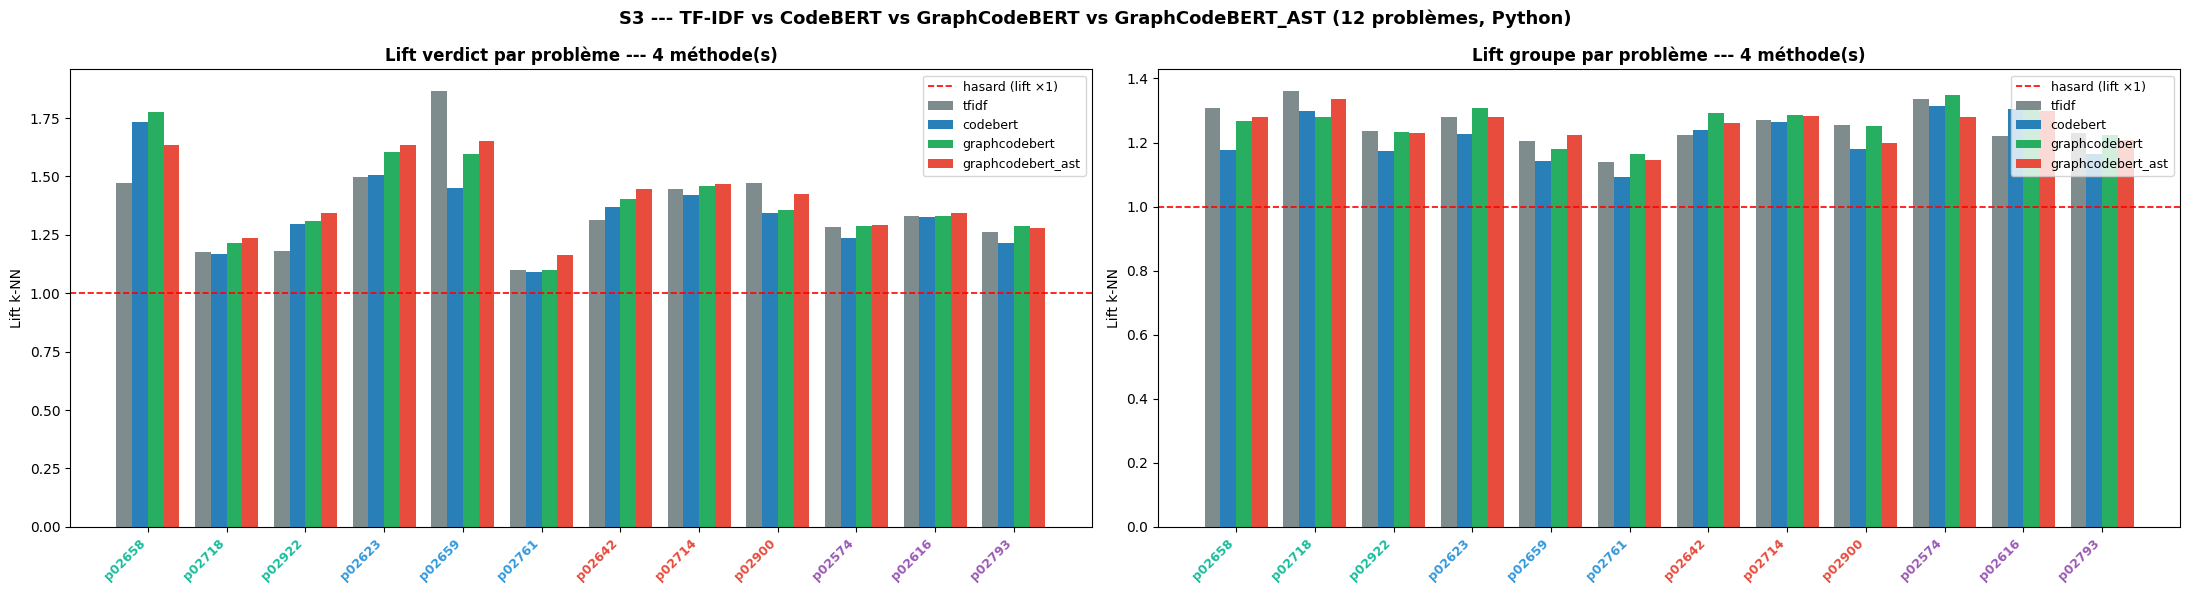

Moyenne des deltas par étiquette :
shape: (2, 5)
┌───────────────────┬──────────────────────┬──────────────────┬──────────────────────┬─────────────┐
│ label             ┆ Δ ast-naïf           ┆ Δ codebert-tfidf ┆ Δ                    ┆ Δ ast-tfidf │
│ ---               ┆ (comparaison centra… ┆ ---              ┆ graphcodebert-tfidf  ┆ ---         │
│ str               ┆ ---                  ┆ f64              ┆ ---                  ┆ f64         │
│                   ┆ f64                  ┆                  ┆ f64                  ┆             │
╞═══════════════════╪══════════════════════╪══════════════════╪══════════════════════╪═════════════╡
│ status_code       ┆ 0.016038             ┆ -0.01954         ┆ 0.027806             ┆ 0.043843    │
│ proficiency_group ┆ -0.011066            ┆ -0.04054         ┆ 0.007561             ┆ -0.003505   │
└───────────────────┴──────────────────────┴──────────────────┴──────────────────────┴─────────────┘

GraphCodeBERT_AST bat GraphCodeBERT naïf 

In [5]:
problems_ordered = (
    df_s3.select(['problem_id', 'difficulty']).unique().sort(['difficulty', 'problem_id'])
)
pid_list  = problems_ordered['problem_id'].to_list()
diff_list = problems_ordered['difficulty'].to_list()

fig, axes = plt.subplots(1, len(TARGET_LABELS), figsize=(11 * len(TARGET_LABELS), 6))
if len(TARGET_LABELS) == 1:
    axes = [axes]

x = np.arange(len(pid_list))
width = 0.8 / max(len(methods_present), 1)
offsets = np.linspace(-0.8 / 2 + width / 2, 0.8 / 2 - width / 2, len(methods_present))

for ax, label in zip(axes, TARGET_LABELS):
    sub = df_s3.filter(pl.col('label') == label)

    for off, m in zip(offsets, methods_present):
        vals = []
        for pid in pid_list:
            row = sub.filter((pl.col('problem_id') == pid) & (pl.col('method') == m))
            vals.append(row['lift'][0] if row.height else np.nan)
        ax.bar(x + off, vals, width,
               label=m.replace('_python_multi12', ''), color=METHOD_COLORS.get(m, '#333'))

    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='hasard (lift ×1)')
    ax.set_xticks(x)
    ax.set_xticklabels(pid_list, rotation=45, ha='right', fontsize=9)
    for tick, diff in zip(ax.get_xticklabels(), diff_list):
        tick.set_color(DIFF_COLORS.get(diff, 'black'))
        tick.set_fontweight('bold')
    ax.set_ylabel('Lift k-NN')
    ax.set_title(f'Lift {LABEL_NAMES[label]} par problème --- {len(methods_present)} méthode(s)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('S3 --- TF-IDF vs CodeBERT vs GraphCodeBERT vs GraphCodeBERT_AST (12 problèmes, Python)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Deltas --- ne suppose pas que les 4 méthodes soient présentes : seules les
# colonnes correspondant à methods_present existent, le reste est calculé
# seulement si les deux méthodes concernées sont chargées.
piv = df_s3.pivot(on='method', index=['problem_id', 'difficulty', 'label'], values='lift')
piv = piv.rename({m: m.replace('_python_multi12', '') for m in methods_present})

short = [m.replace('_python_multi12', '') for m in methods_present]
delta_cols = []
if 'graphcodebert_ast' in short and 'graphcodebert' in short:
    piv = piv.with_columns((pl.col('graphcodebert_ast') - pl.col('graphcodebert')).alias('d_ast_naive'))
    delta_cols.append(('d_ast_naive', 'Δ ast-naïf (comparaison centrale de ce notebook)'))
if 'codebert' in short and 'tfidf' in short:
    piv = piv.with_columns((pl.col('codebert') - pl.col('tfidf')).alias('d_code_tfidf'))
    delta_cols.append(('d_code_tfidf', 'Δ codebert-tfidf'))
if 'graphcodebert' in short and 'tfidf' in short:
    piv = piv.with_columns((pl.col('graphcodebert') - pl.col('tfidf')).alias('d_graph_tfidf'))
    delta_cols.append(('d_graph_tfidf', 'Δ graphcodebert-tfidf'))
if 'graphcodebert_ast' in short and 'tfidf' in short:
    piv = piv.with_columns((pl.col('graphcodebert_ast') - pl.col('tfidf')).alias('d_ast_tfidf'))
    delta_cols.append(('d_ast_tfidf', 'Δ ast-tfidf'))

if delta_cols:
    print("Moyenne des deltas par étiquette :")
    print(piv.group_by('label').agg([pl.col(c).mean().alias(name) for c, name in delta_cols]))
else:
    print("Aucun delta calculable pour l'instant (moins de 2 méthodes chargées).")

if 'd_ast_naive' in piv.columns:
    print("\nGraphCodeBERT_AST bat GraphCodeBERT naïf sur combien de problèmes ?")
    for lbl in TARGET_LABELS:
        sub = piv.filter(pl.col('label') == lbl)
        wins = sub.filter(pl.col('d_ast_naive') > 0).height
        print(f"  {LABEL_NAMES[lbl]:8s} : {wins}/{sub.height} problèmes")
else:
    print("\nΔ(ast - naïf) pas encore disponible --- graphcodebert_ast n'est pas chargé (voir S2).")

## S4 --- Heatmaps de confusion par voisinage
### S4 --- Neighbor Confusion Heatmaps

Mêmes deux problèmes de référence que NB11/NB12 (p02659, p02658), pour rester
directement comparable --- une ligne de plus (GraphCodeBERT_AST, si chargé) sur
une grille déjà connue.

---

Same two reference problems as NB11/NB12 (p02659, p02658), to stay directly
comparable --- one more row (GraphCodeBERT_AST, if loaded) on an
already-familiar grid.

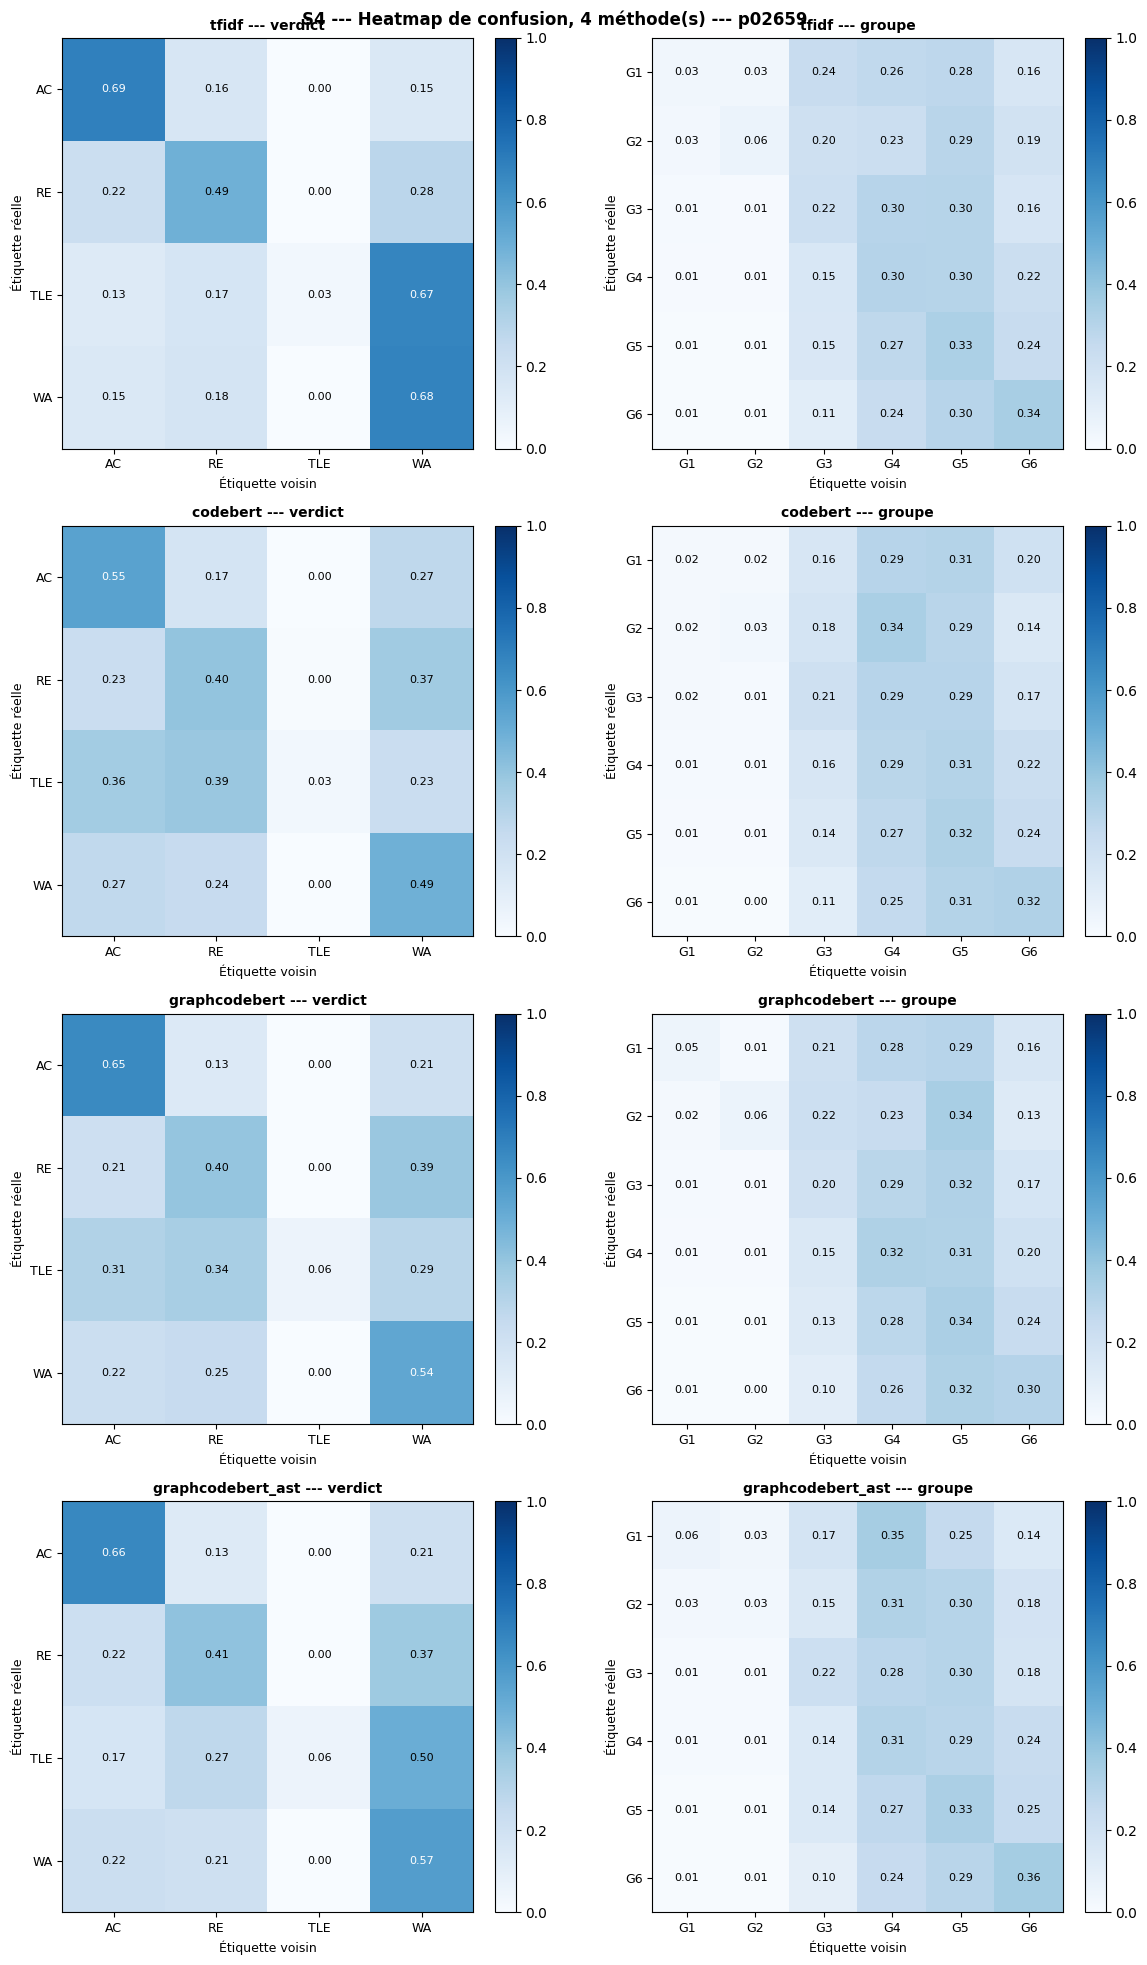

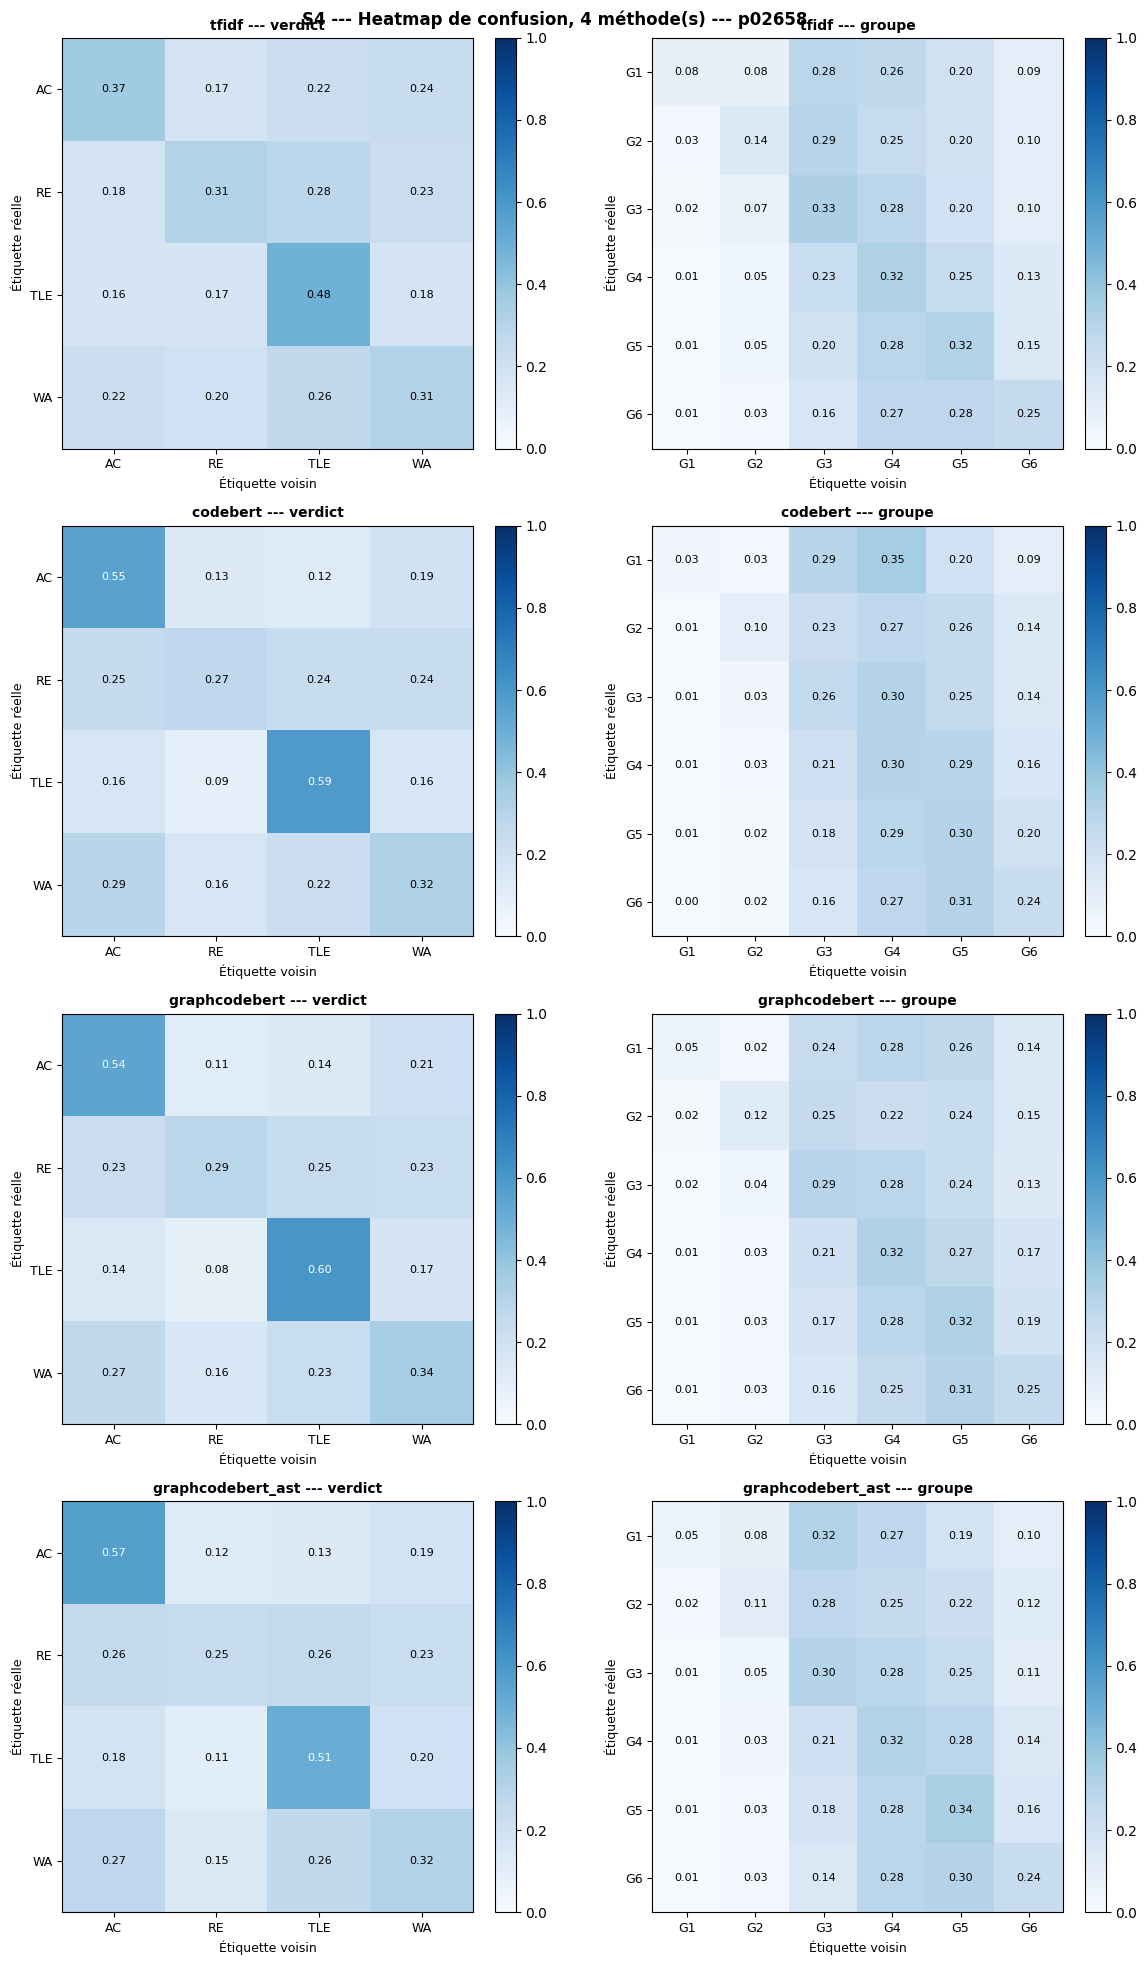

In [6]:
from sklearn.neighbors import NearestNeighbors as _NNs4

TARGETS_S4 = ['p02659', 'p02658']

for pid in TARGETS_S4:
    fig, axes = plt.subplots(len(methods_present), len(TARGET_LABELS),
                             figsize=(6 * len(TARGET_LABELS), 5 * len(methods_present)))
    axes = np.atleast_2d(axes)
    if axes.shape != (len(methods_present), len(TARGET_LABELS)):
        axes = axes.reshape(len(methods_present), len(TARGET_LABELS))

    for row_i, m in enumerate(methods_present):
        meta = df_meta_4[m]
        idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
        sub_emb = embeddings_4[m][idx]
        sub_meta = meta[idx]

        nbrs = _NNs4(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
        nbrs.fit(sub_emb)
        _, nn_idx = nbrs.kneighbors(sub_emb)

        for col_i, label in enumerate(TARGET_LABELS):
            ax = axes[row_i, col_i]
            labels_arr = sub_meta[label].to_numpy()
            classes = sorted(set(labels_arr))
            cls_idx = {c: i for i, c in enumerate(classes)}
            n_cls = len(classes)

            matrix = np.zeros((n_cls, n_cls), dtype=float)
            for i, true_v in enumerate(labels_arr):
                for j in nn_idx[i, 1:]:
                    matrix[cls_idx[true_v], cls_idx[labels_arr[j]]] += 1
            row_sums = matrix.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            matrix /= row_sums

            im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(n_cls)); ax.set_xticklabels(classes, fontsize=9)
            ax.set_yticks(range(n_cls)); ax.set_yticklabels(classes, fontsize=9)
            ax.set_xlabel('Étiquette voisin', fontsize=9)
            ax.set_ylabel('Étiquette réelle', fontsize=9)
            ax.set_title(f'{m.replace("_python_multi12", "")} --- {LABEL_NAMES[label]}',
                        fontsize=10, fontweight='bold')
            for r in range(n_cls):
                for c in range(n_cls):
                    ax.text(c, r, f'{matrix[r,c]:.2f}', ha='center', va='center',
                            fontsize=8, color='white' if matrix[r,c] > 0.5 else 'black')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'S4 --- Heatmap de confusion, {len(methods_present)} méthode(s) --- {pid}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## S5 --- Cartes UMAP : un problème par difficulté
### S5 --- UMAP Maps: One Problem per Difficulty

Comme en NB12 S4, UMAP seul ne montrera probablement aucune séparation nette
--- déjà su (NB11 S6, NB12 S4/S5) --- mais gardé pour la comparaison directe
avec t-SNE (S6) sur les mêmes points.

Sélection des problèmes : contrairement à NB12 (qui reprenait un tableau déjà
calculé), on sélectionne ici, **pour chaque difficulté, le problème où
Δ(GraphCodeBERT_AST − GraphCodeBERT) est le plus grand** --- calculé à partir
de `piv` en S3, pas une valeur recopiée --- pour rester cohérent avec la
question centrale de ce notebook plutôt que de réutiliser une sélection
optimisée pour une autre comparaison.

---

As in NB12 S4, UMAP alone will likely show no clean separation --- already
known (NB11 S6, NB12 S4/S5) --- but kept for direct comparison with t-SNE (S6)
on the same points.

Problem selection: unlike NB12 (which reused an already-computed table), we
select here, **for each difficulty, the problem where
Δ(GraphCodeBERT_AST − GraphCodeBERT) is largest** --- computed from `piv` in
S3, not a copied-in value --- to stay consistent with this notebook's central
question rather than reusing a selection optimized for a different comparison.

Problème sélectionné par difficulté (verdict, Δ ast-naïf le plus grand) :
  B : p02922  (Δ = +0.035)
  C : p02761  (Δ = +0.066)
  D : p02900  (Δ = +0.065)
  E : p02616  (Δ = +0.012)


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


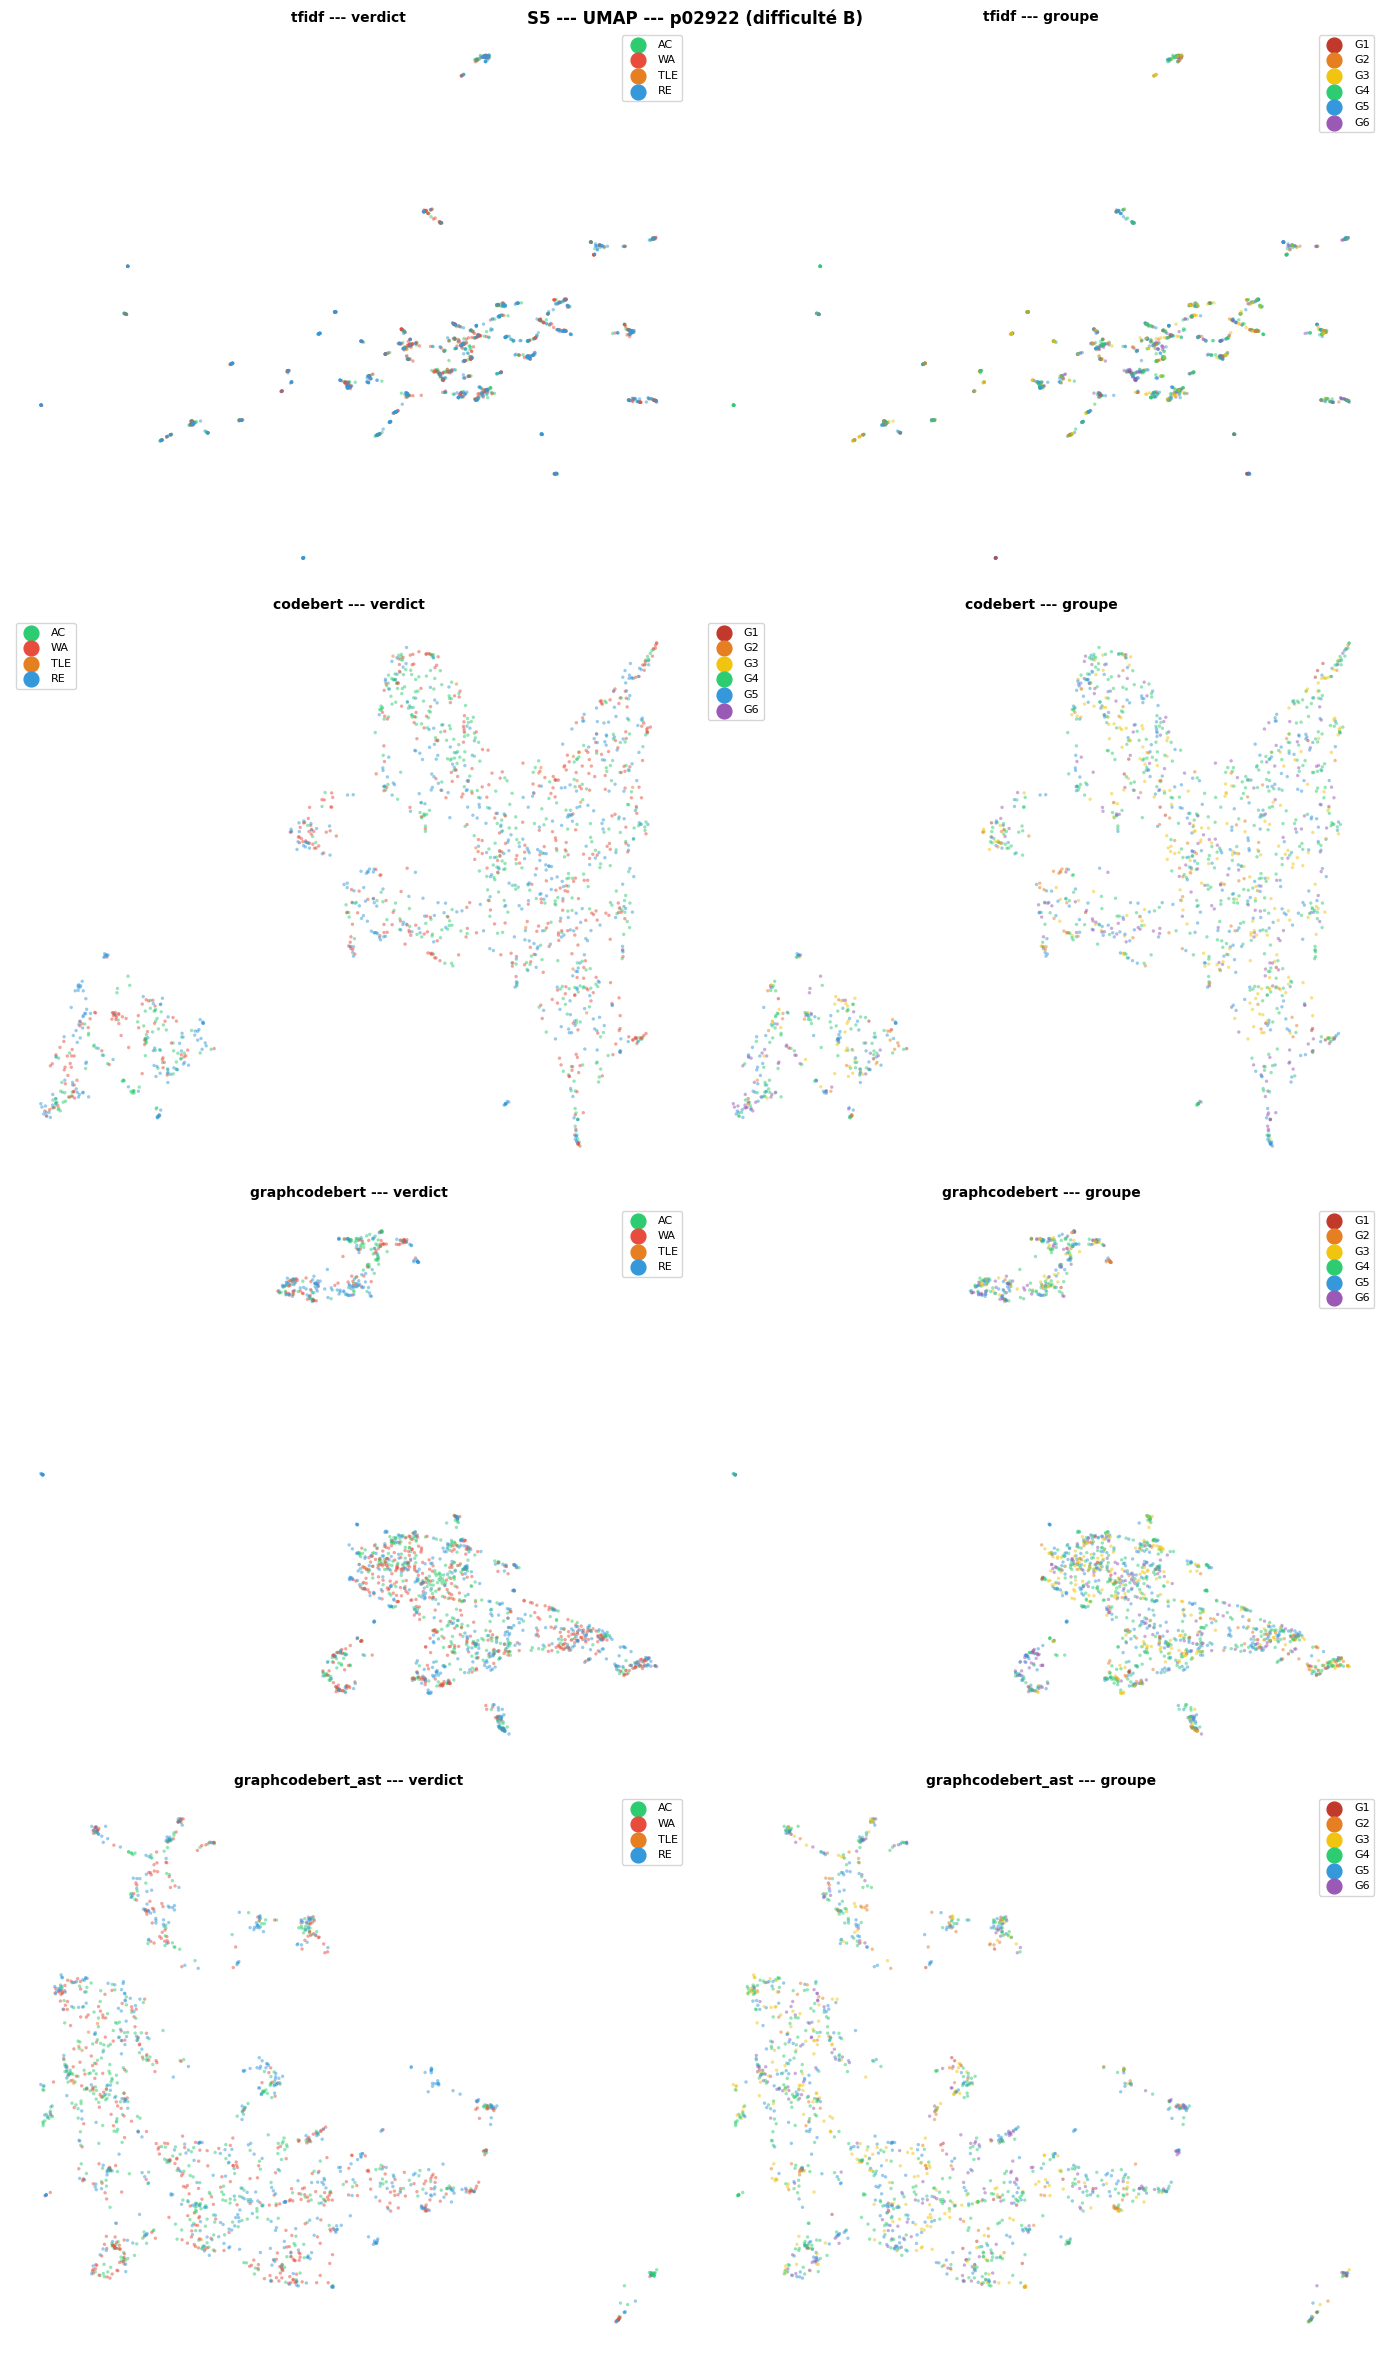

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


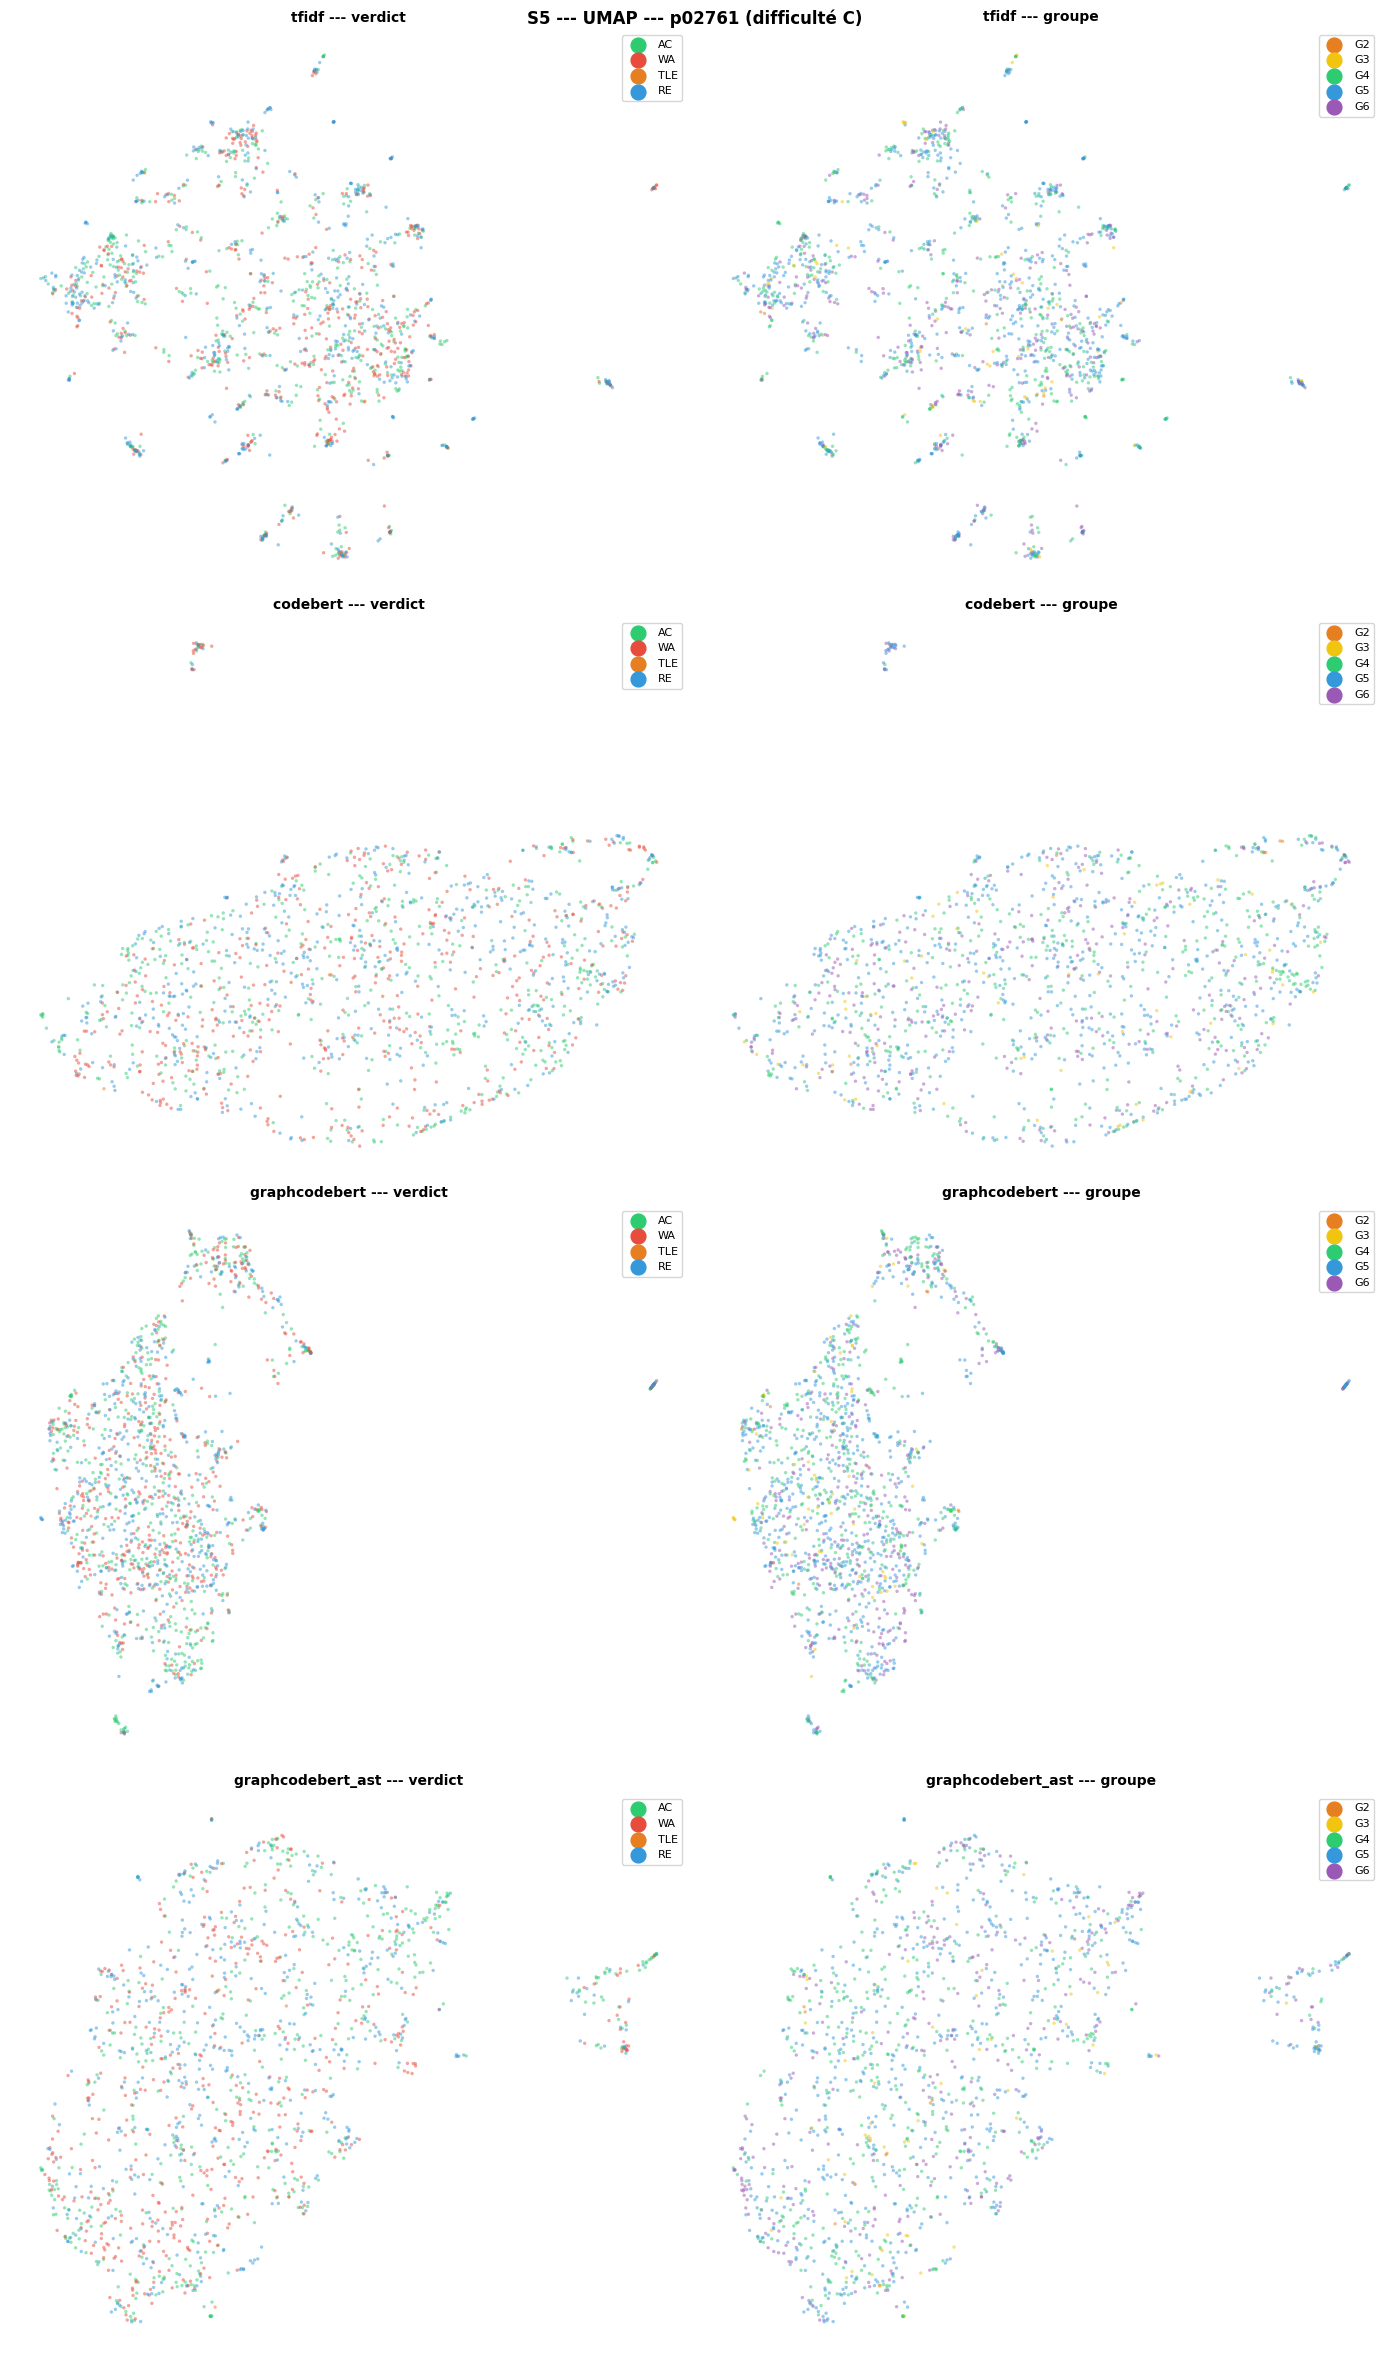

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


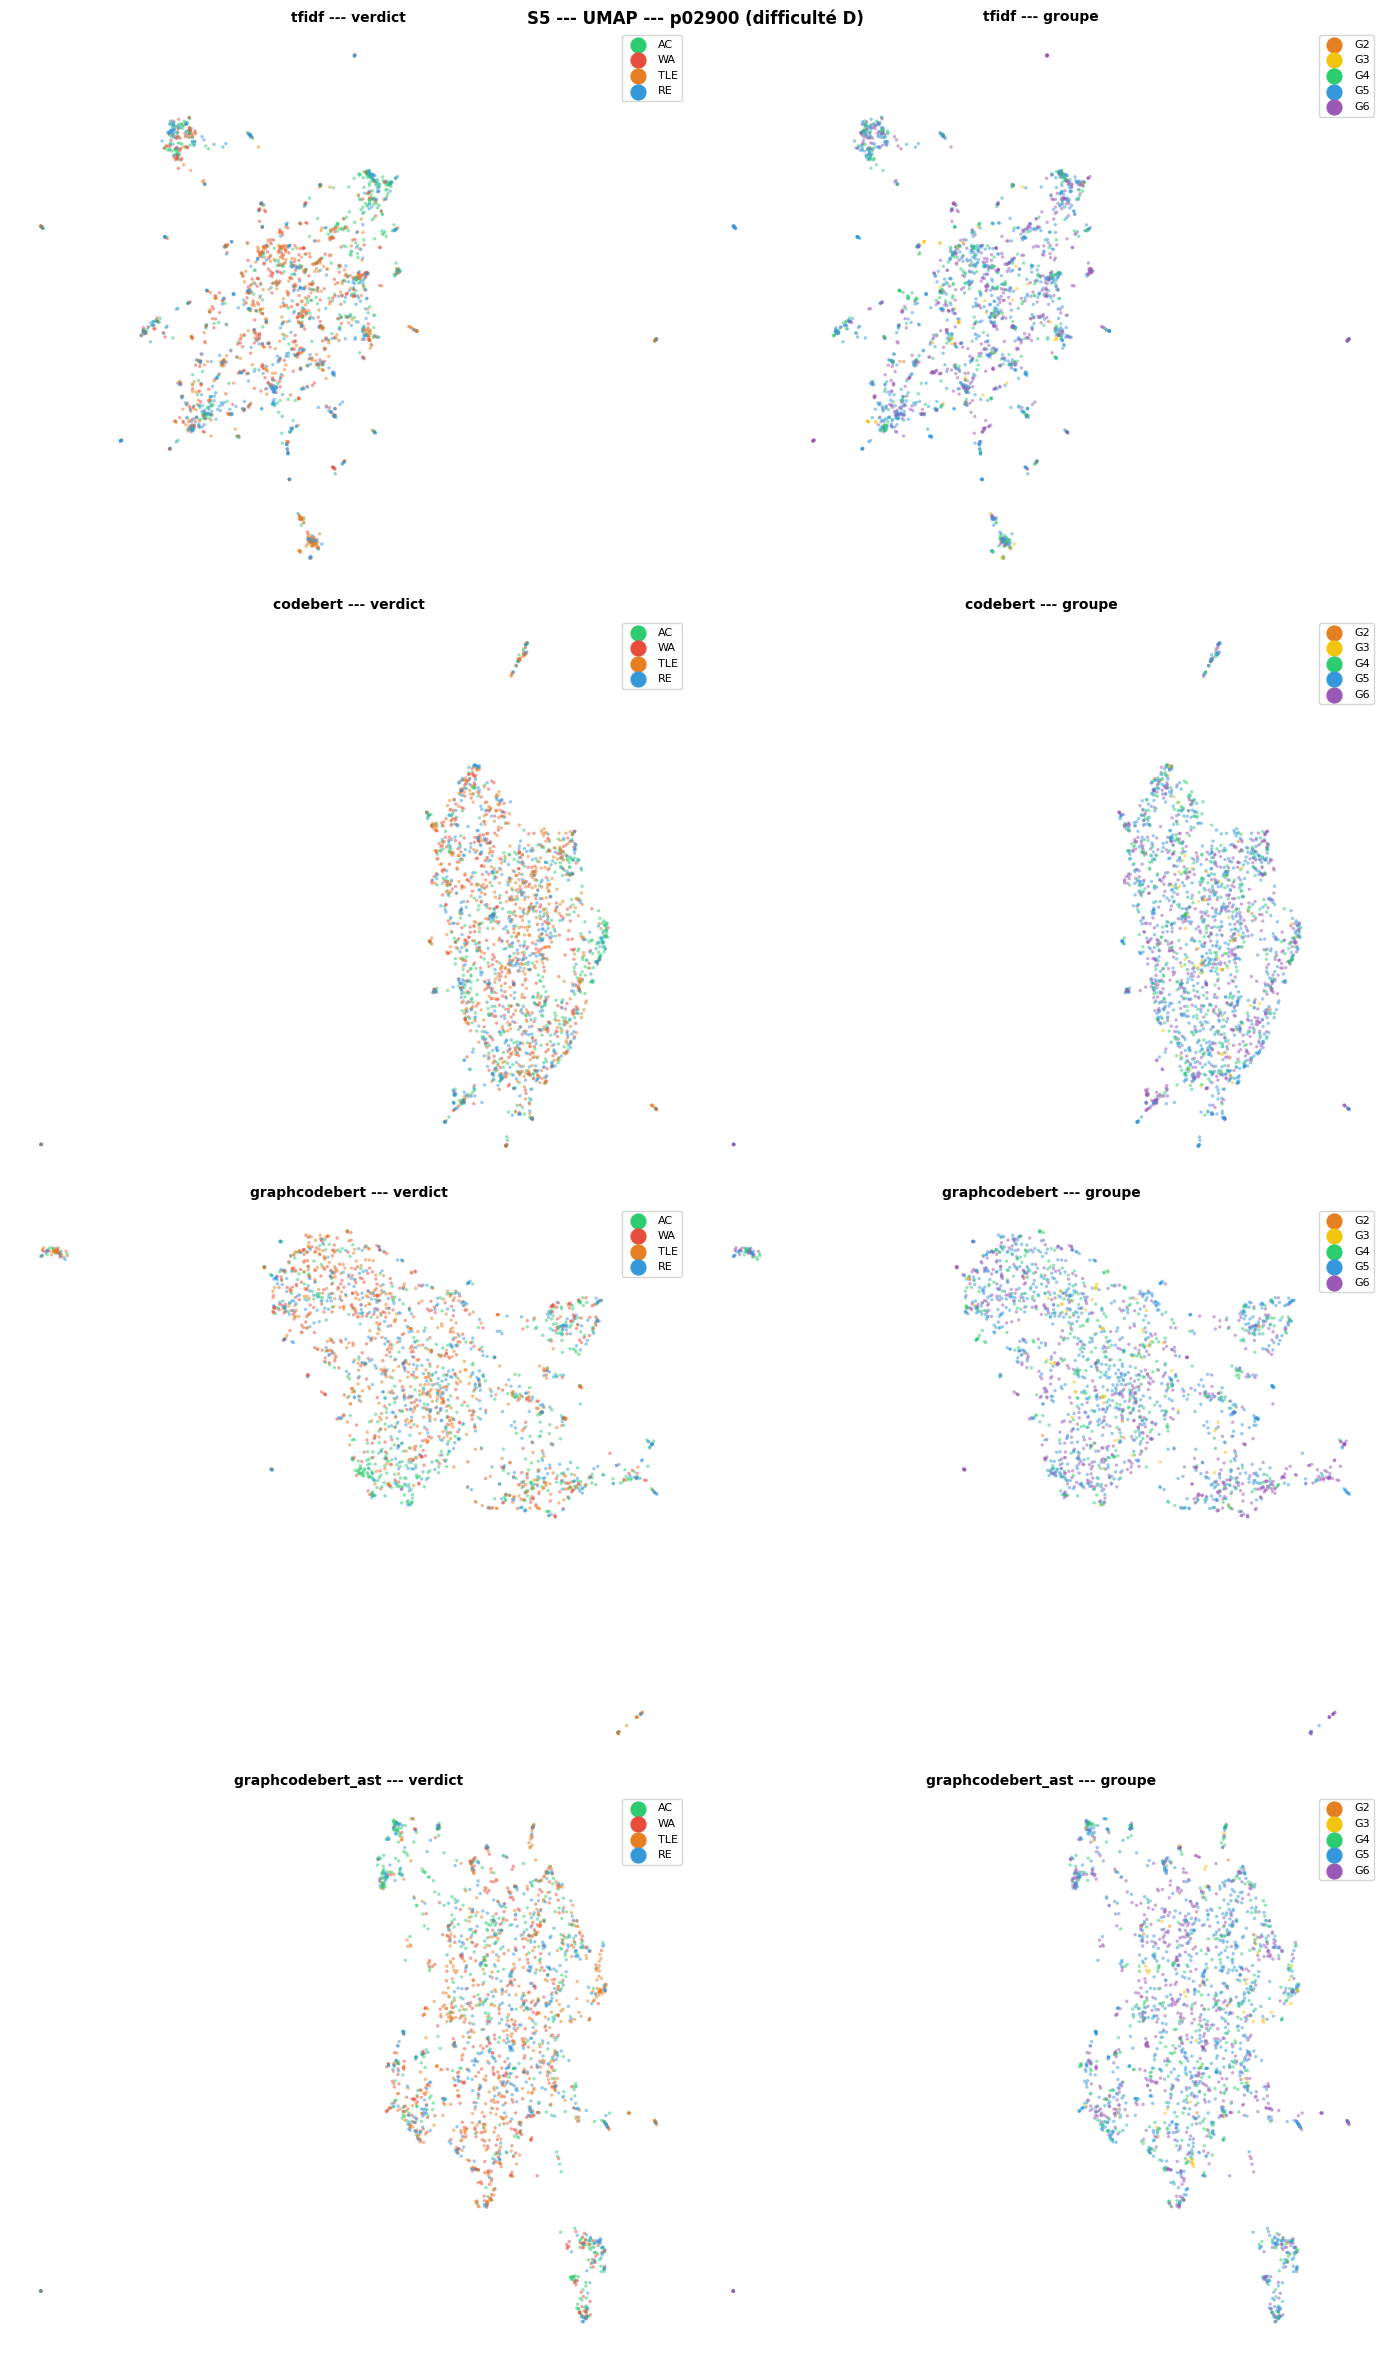

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/pytho

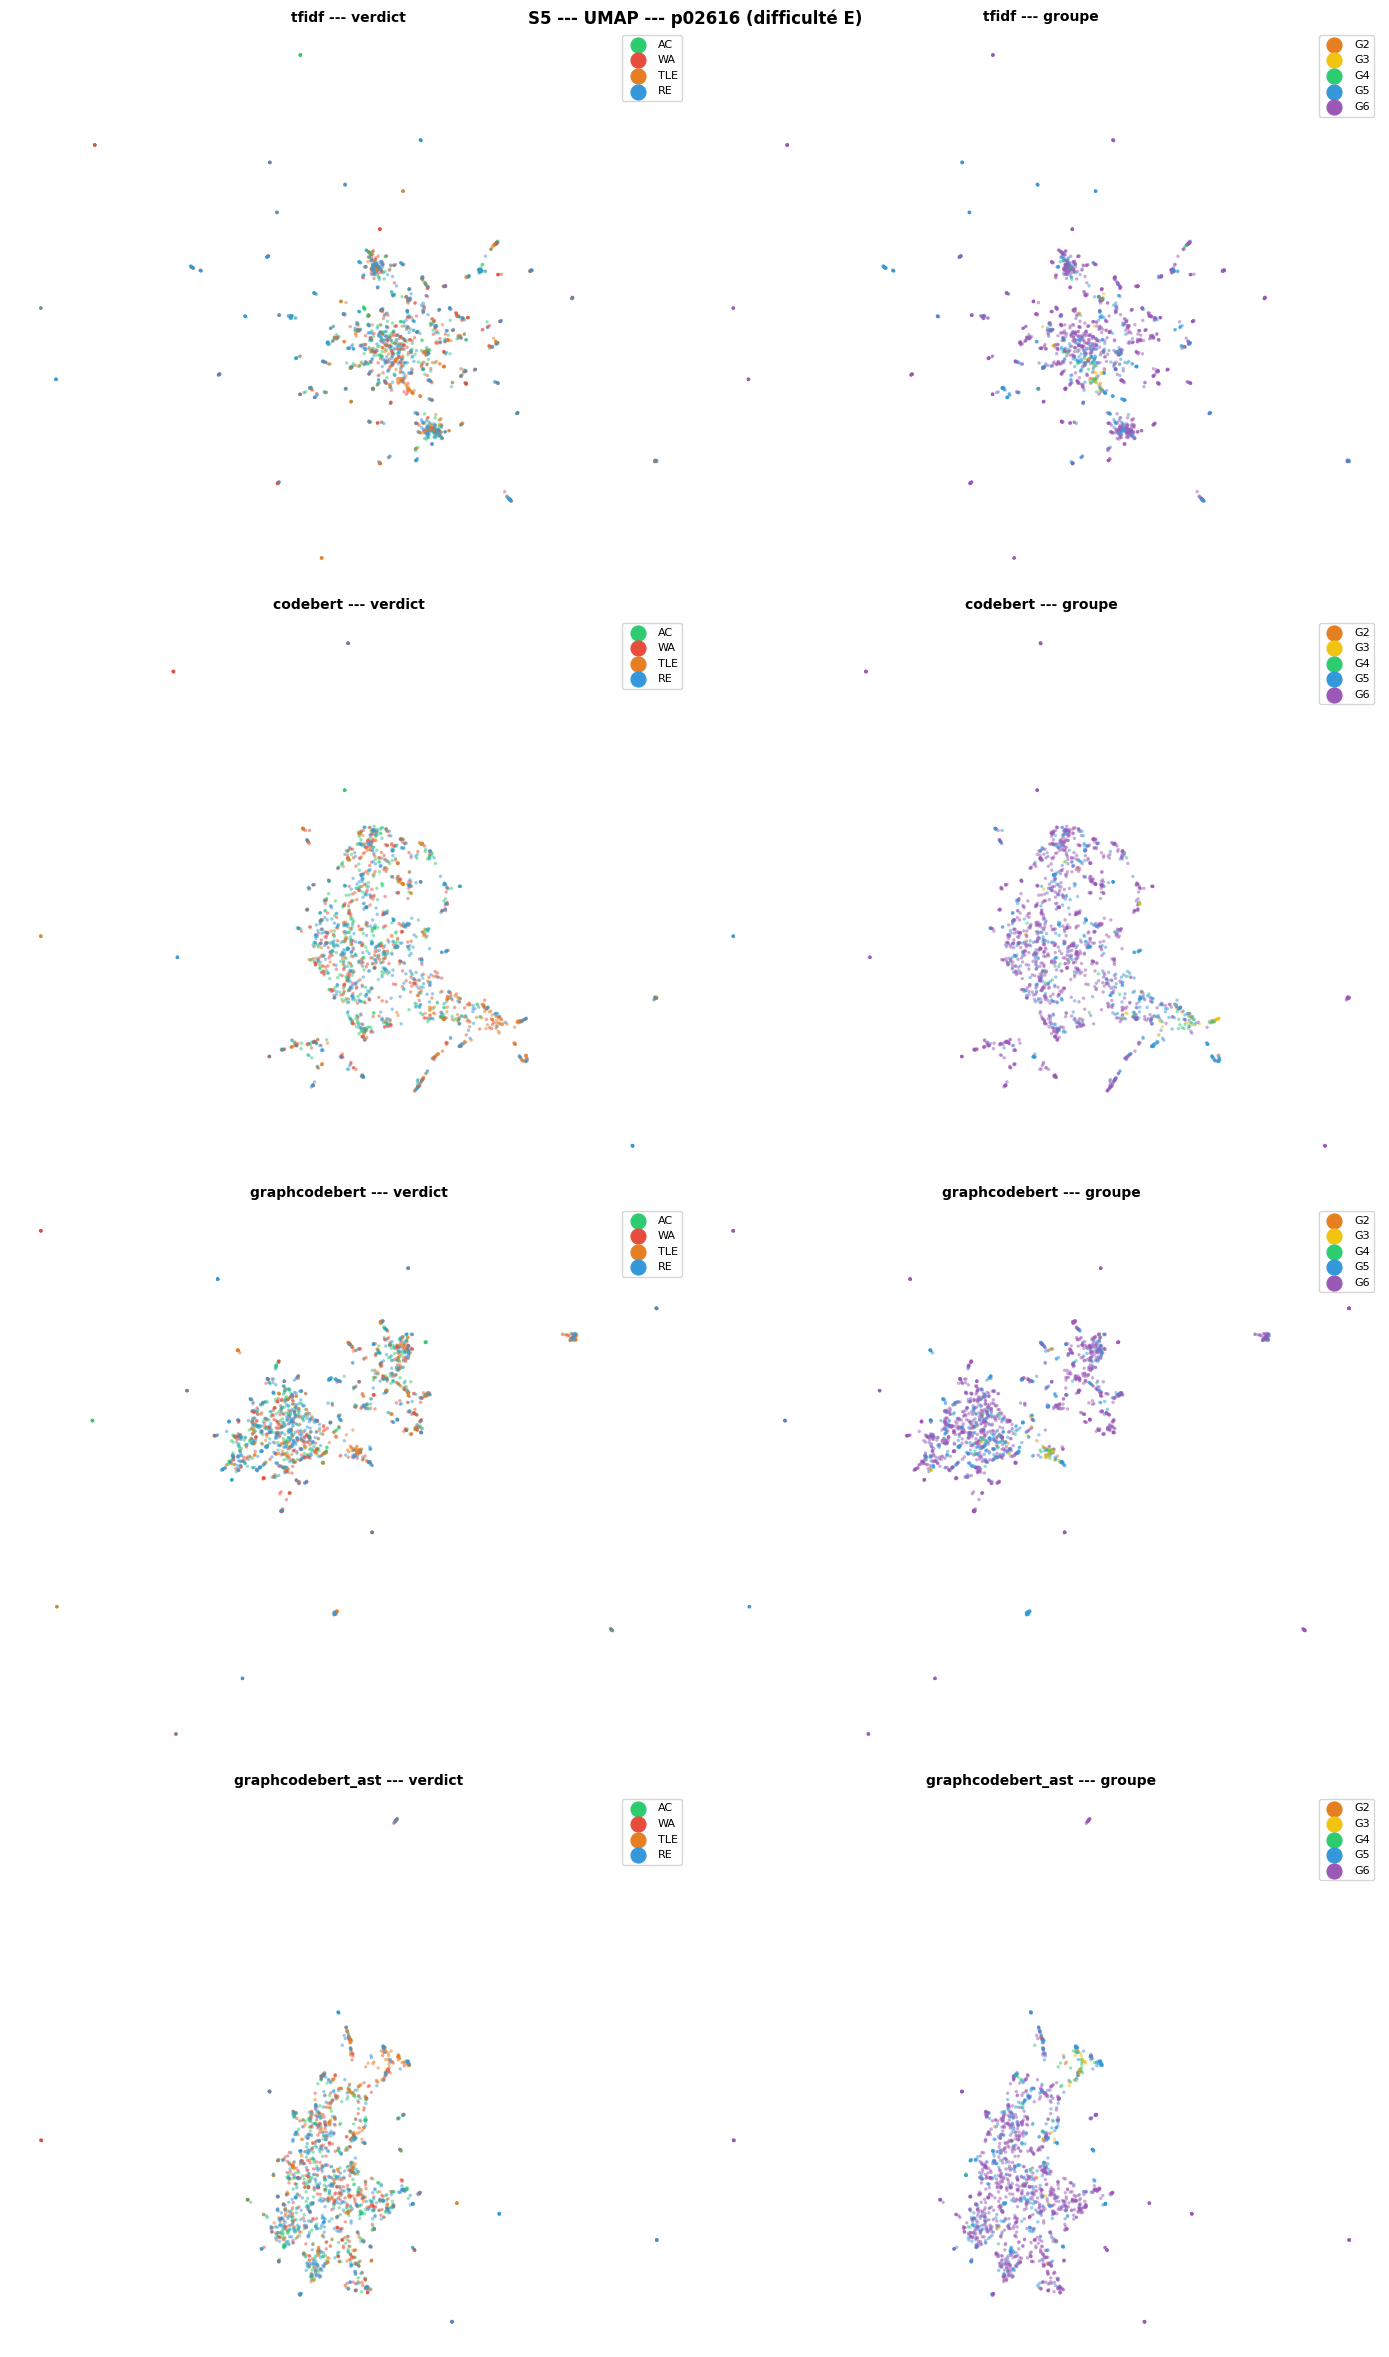

In [7]:
import umap

if 'd_ast_naive' not in piv.columns:
    print("Δ(ast - naïf) indisponible (graphcodebert_ast pas encore chargé --- voir S2/S3).")
    print("Section sautée --- relancer S2, S3 puis cette cellule une fois le corpus prêt.")
    best_per_diff = {}
else:
    best_per_diff = {}
    for diff in DIFFS_ORDER:
        sub = piv.filter((pl.col('difficulty') == diff) & (pl.col('label') == 'status_code'))
        if sub.height == 0:
            continue
        best_row = sub.sort('d_ast_naive', descending=True).row(0, named=True)
        best_per_diff[diff] = best_row['problem_id']

    print("Problème sélectionné par difficulté (verdict, Δ ast-naïf le plus grand) :")
    for diff, pid in best_per_diff.items():
        d = piv.filter((pl.col('problem_id') == pid) & (pl.col('label') == 'status_code'))['d_ast_naive'][0]
        print(f"  {diff} : {pid}  (Δ = {d:+.3f})")

    for diff, pid in best_per_diff.items():
        fig, axes = plt.subplots(len(methods_present), len(TARGET_LABELS),
                                 figsize=(7 * len(TARGET_LABELS), 6 * len(methods_present)))
        axes = np.atleast_2d(axes)
        if axes.shape != (len(methods_present), len(TARGET_LABELS)):
            axes = axes.reshape(len(methods_present), len(TARGET_LABELS))

        for row_i, m in enumerate(methods_present):
            meta = df_meta_4[m]
            idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
            sub_emb = embeddings_4[m][idx]
            sub_meta = meta[idx]

            reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                                random_state=42, metric='cosine')
            proj = reducer.fit_transform(sub_emb)

            for col_i, label in enumerate(TARGET_LABELS):
                ax = axes[row_i, col_i]
                colors_map = STATUS_COLORS if label == 'status_code' else GROUP_COLORS
                order = STATUSES_ORDER if label == 'status_code' else GROUPS_ORDER
                vals = sub_meta[label].to_list()
                ax.scatter(proj[:, 0], proj[:, 1],
                          c=[colors_map.get(v, '#aaaaaa') for v in vals],
                          s=6, alpha=0.5, linewidths=0)
                for v in order:
                    if v in vals:
                        ax.scatter([], [], c=colors_map[v], s=35, label=v)
                ax.legend(fontsize=8, markerscale=1.8, framealpha=0.8)
                ax.set_title(f'{m.replace("_python_multi12", "")} --- {LABEL_NAMES[label]}',
                            fontsize=10, fontweight='bold')
                ax.axis('off')

        plt.suptitle(f'S5 --- UMAP --- {pid} (difficulté {diff})', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

## S6 --- Cartes t-SNE : mêmes problèmes, autre projection
### S6 --- t-SNE Maps: Same Problems, Different Projection

Mêmes problèmes que S5, même disposition --- comparaison directe entre les deux
méthodes de projection (voir NB11 S6 pour le mécanisme).

---

Same problems as S5, same layout --- direct comparison between the two
projection methods (see NB11 S6 for the mechanism).

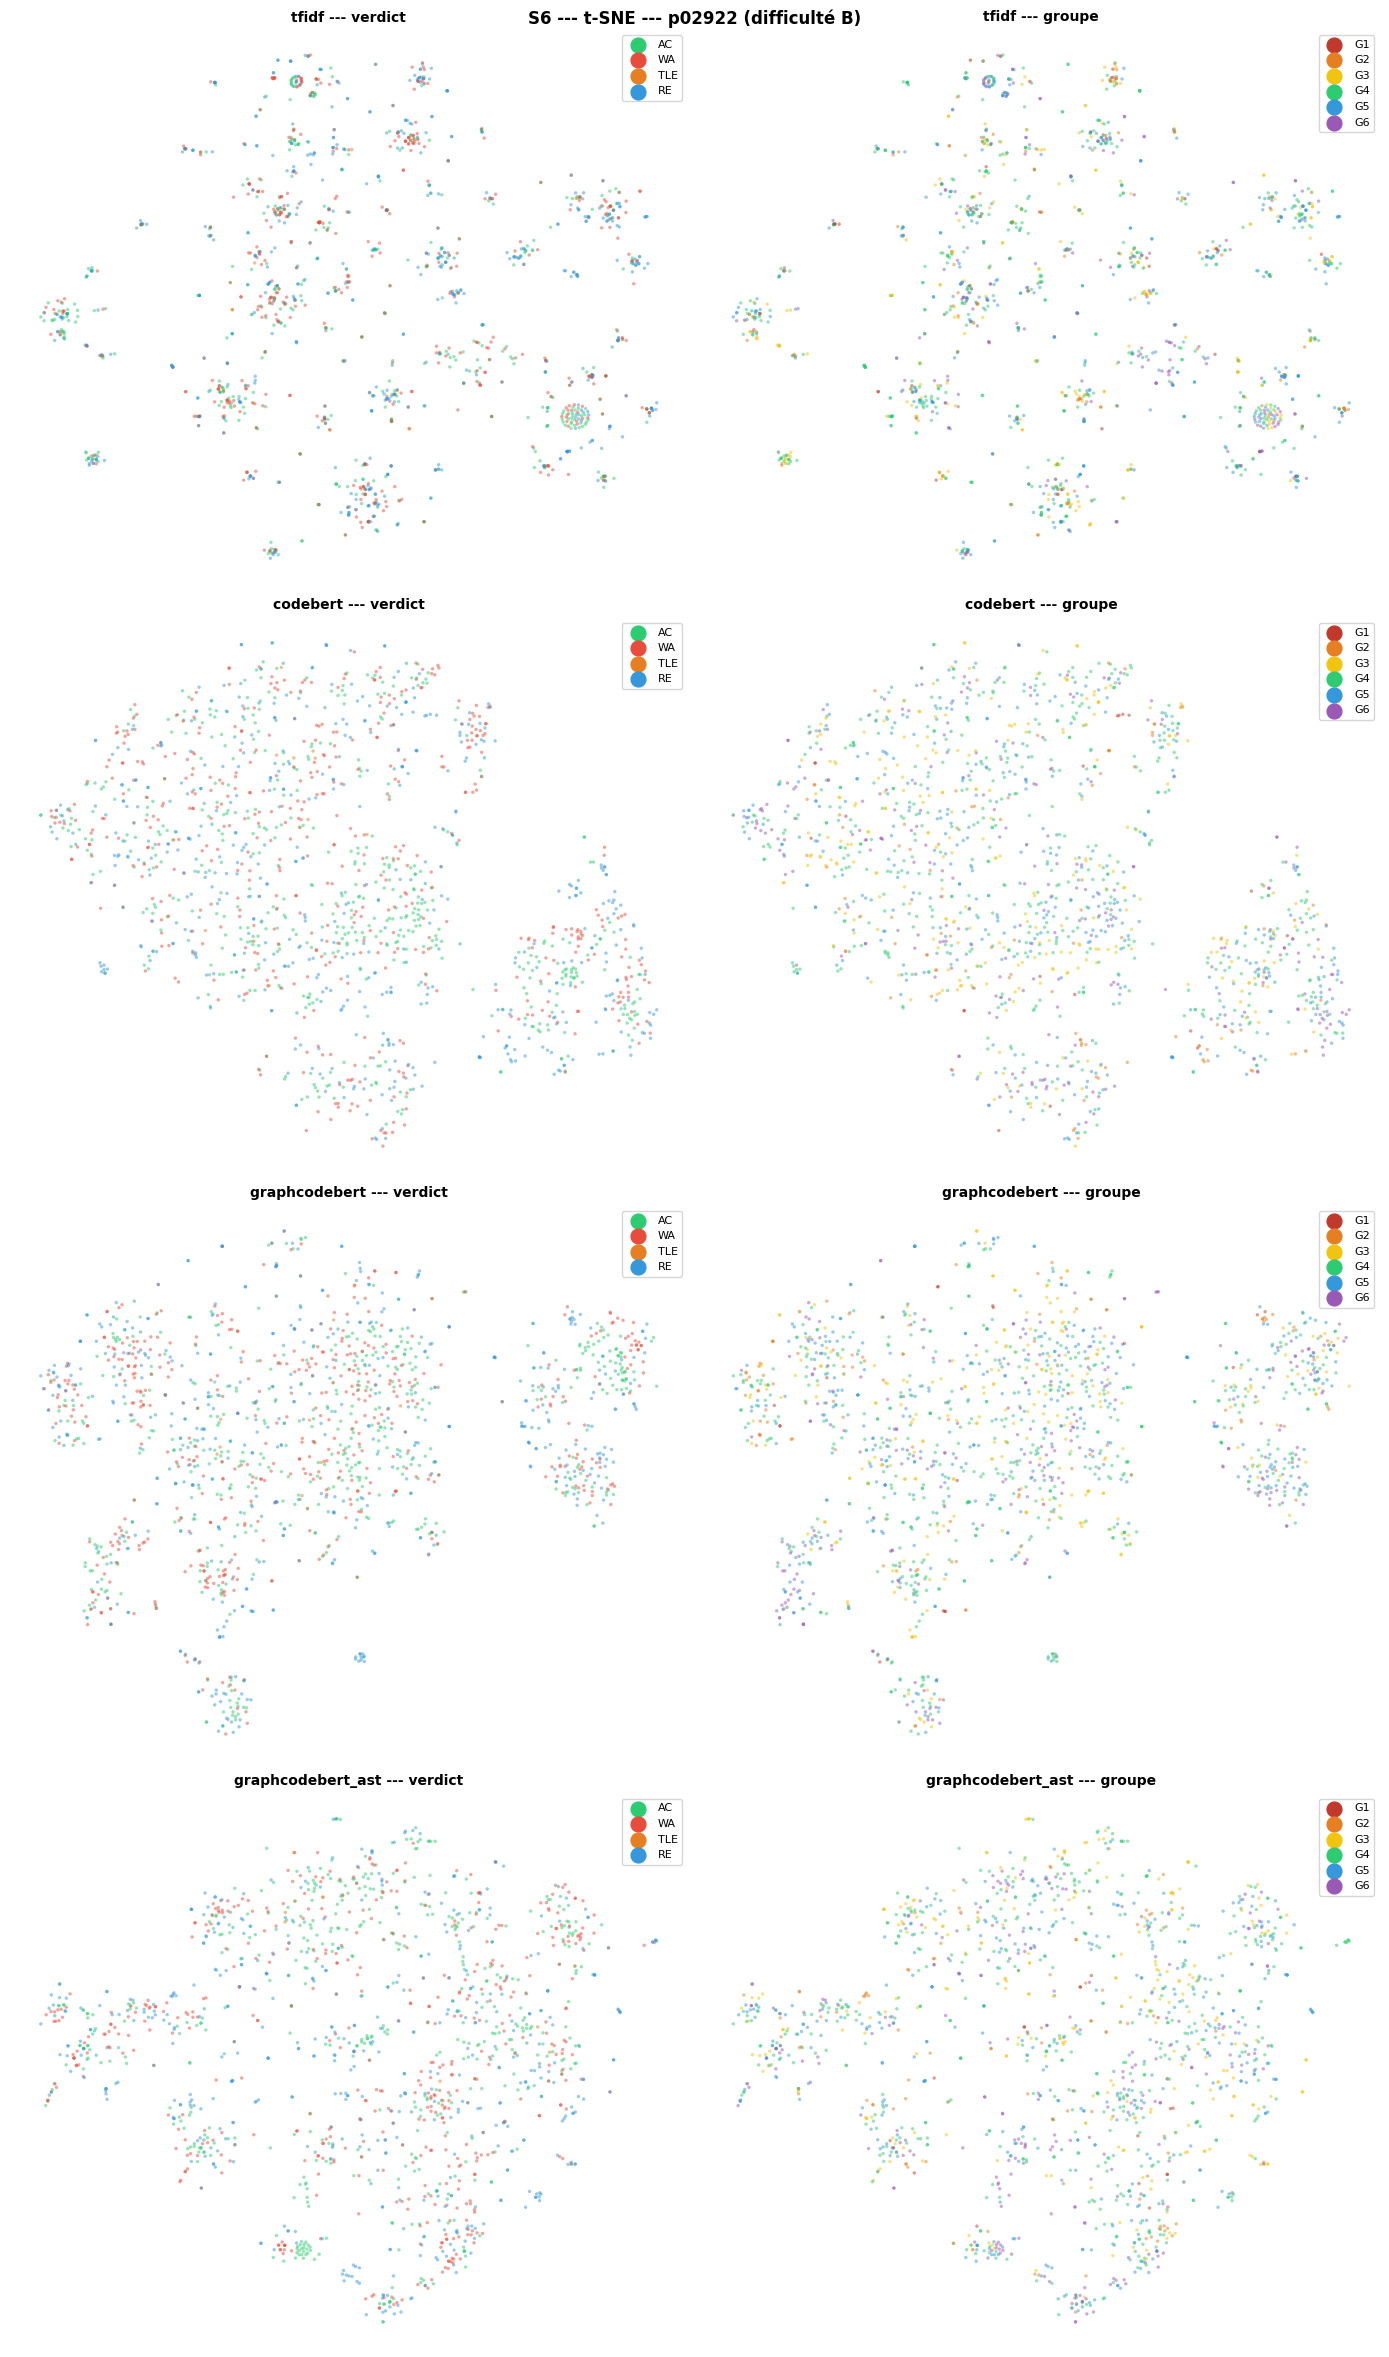

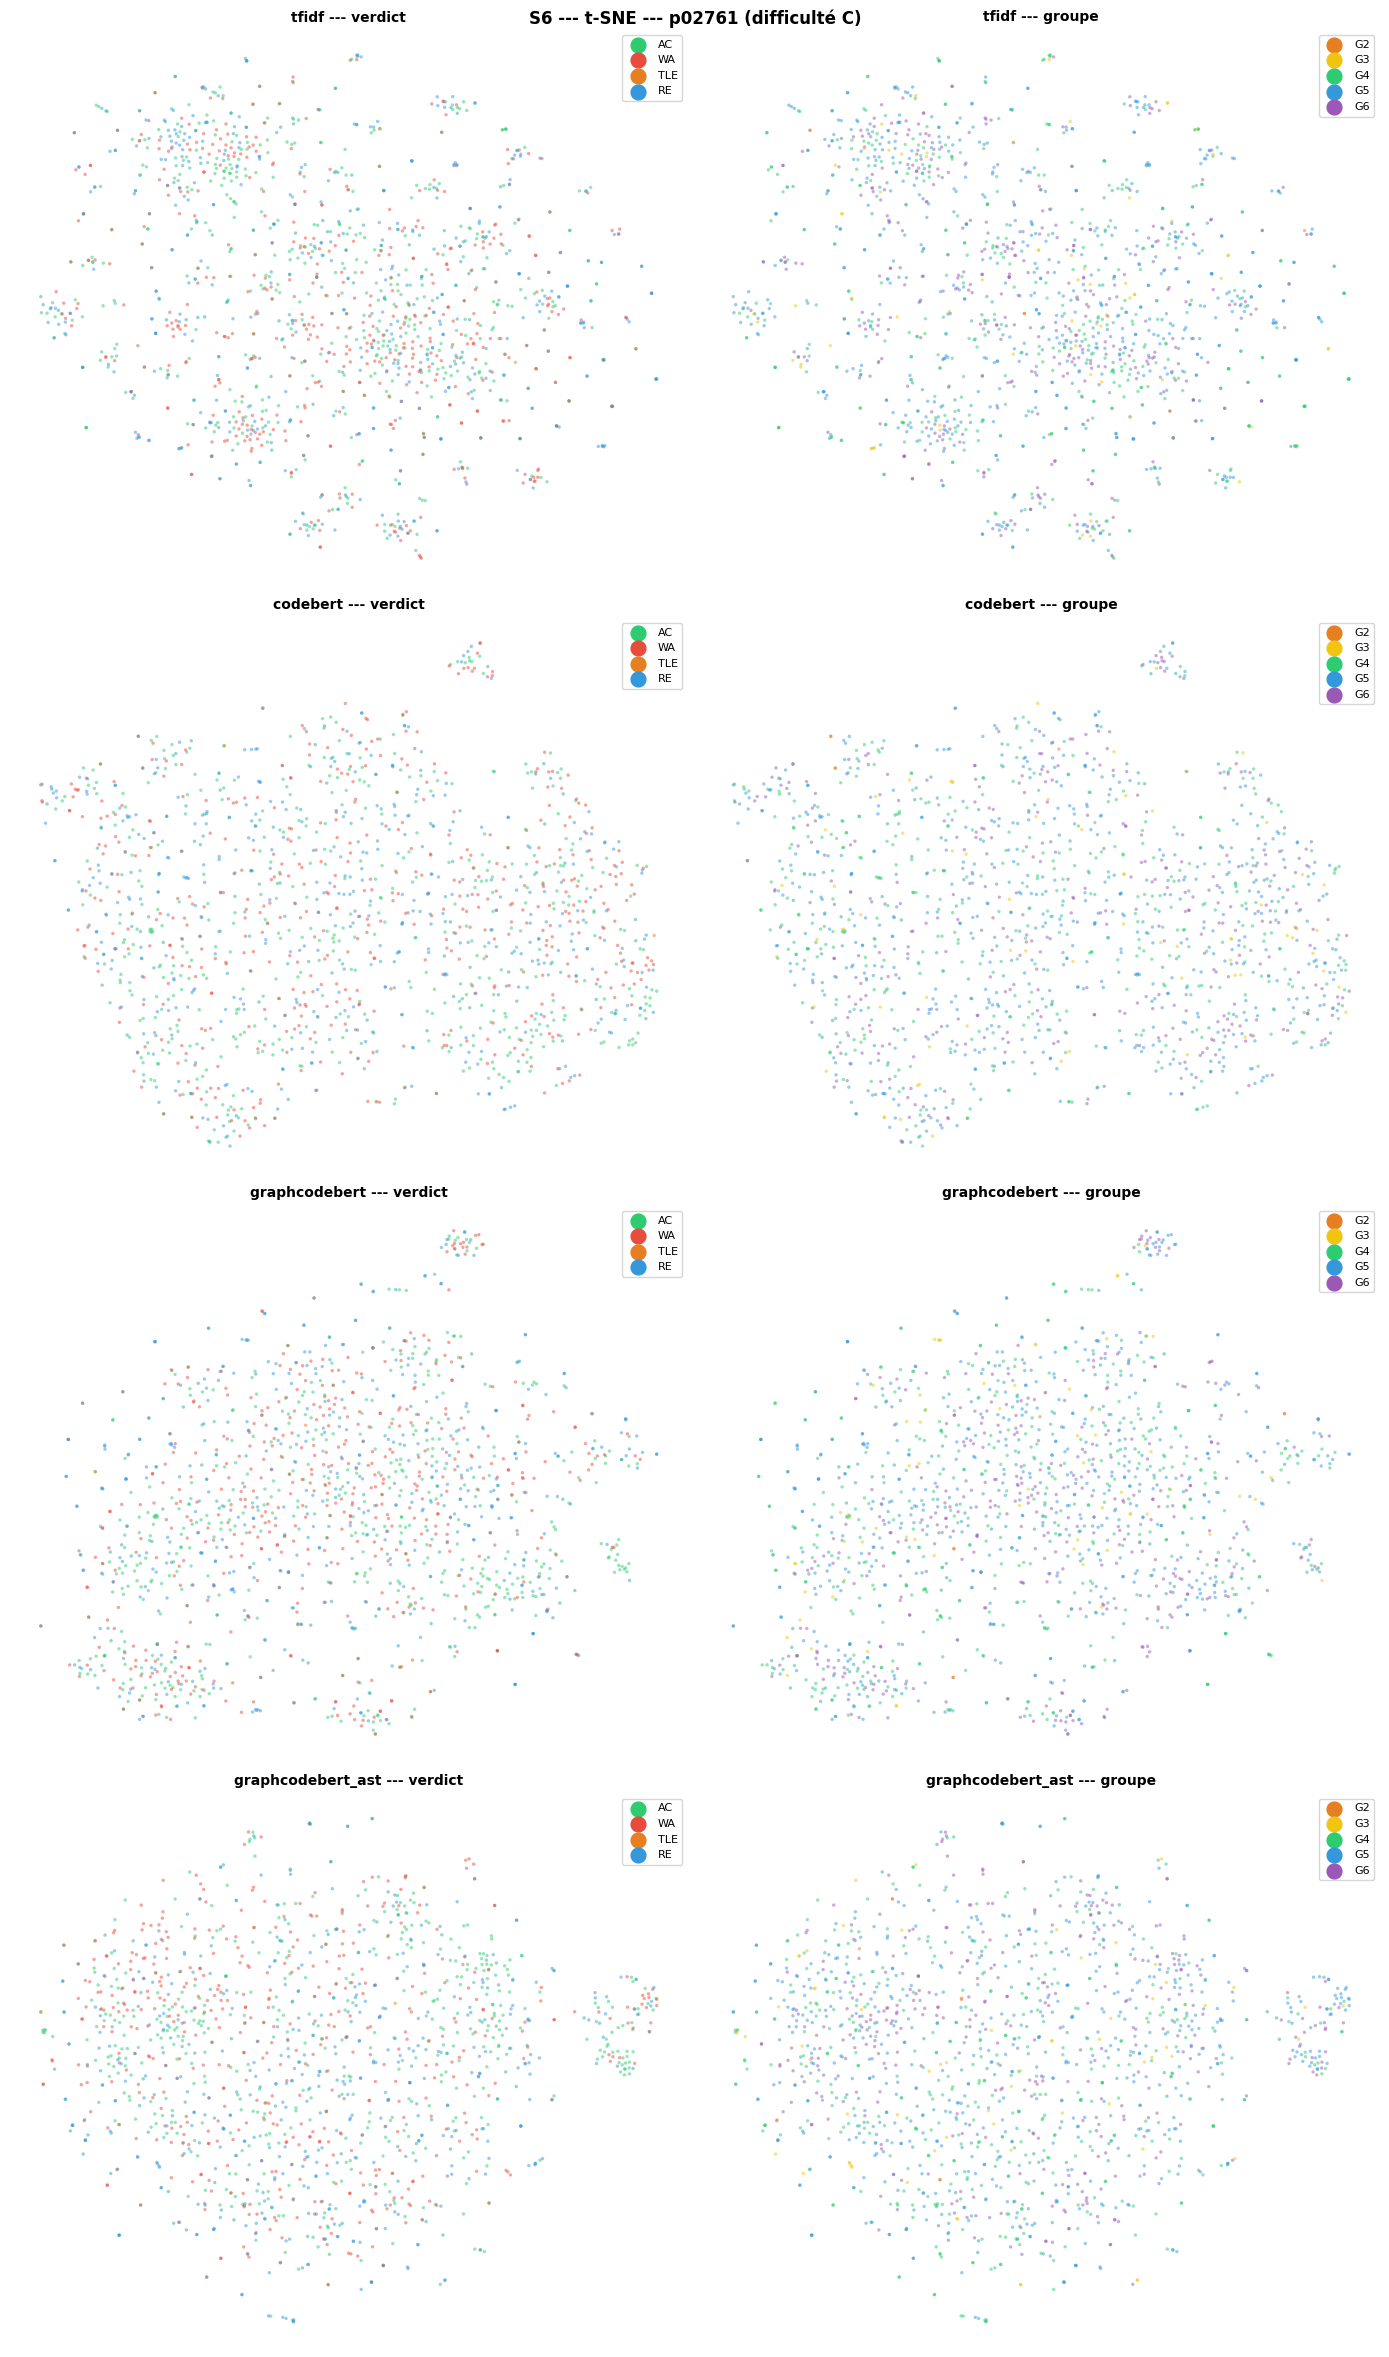

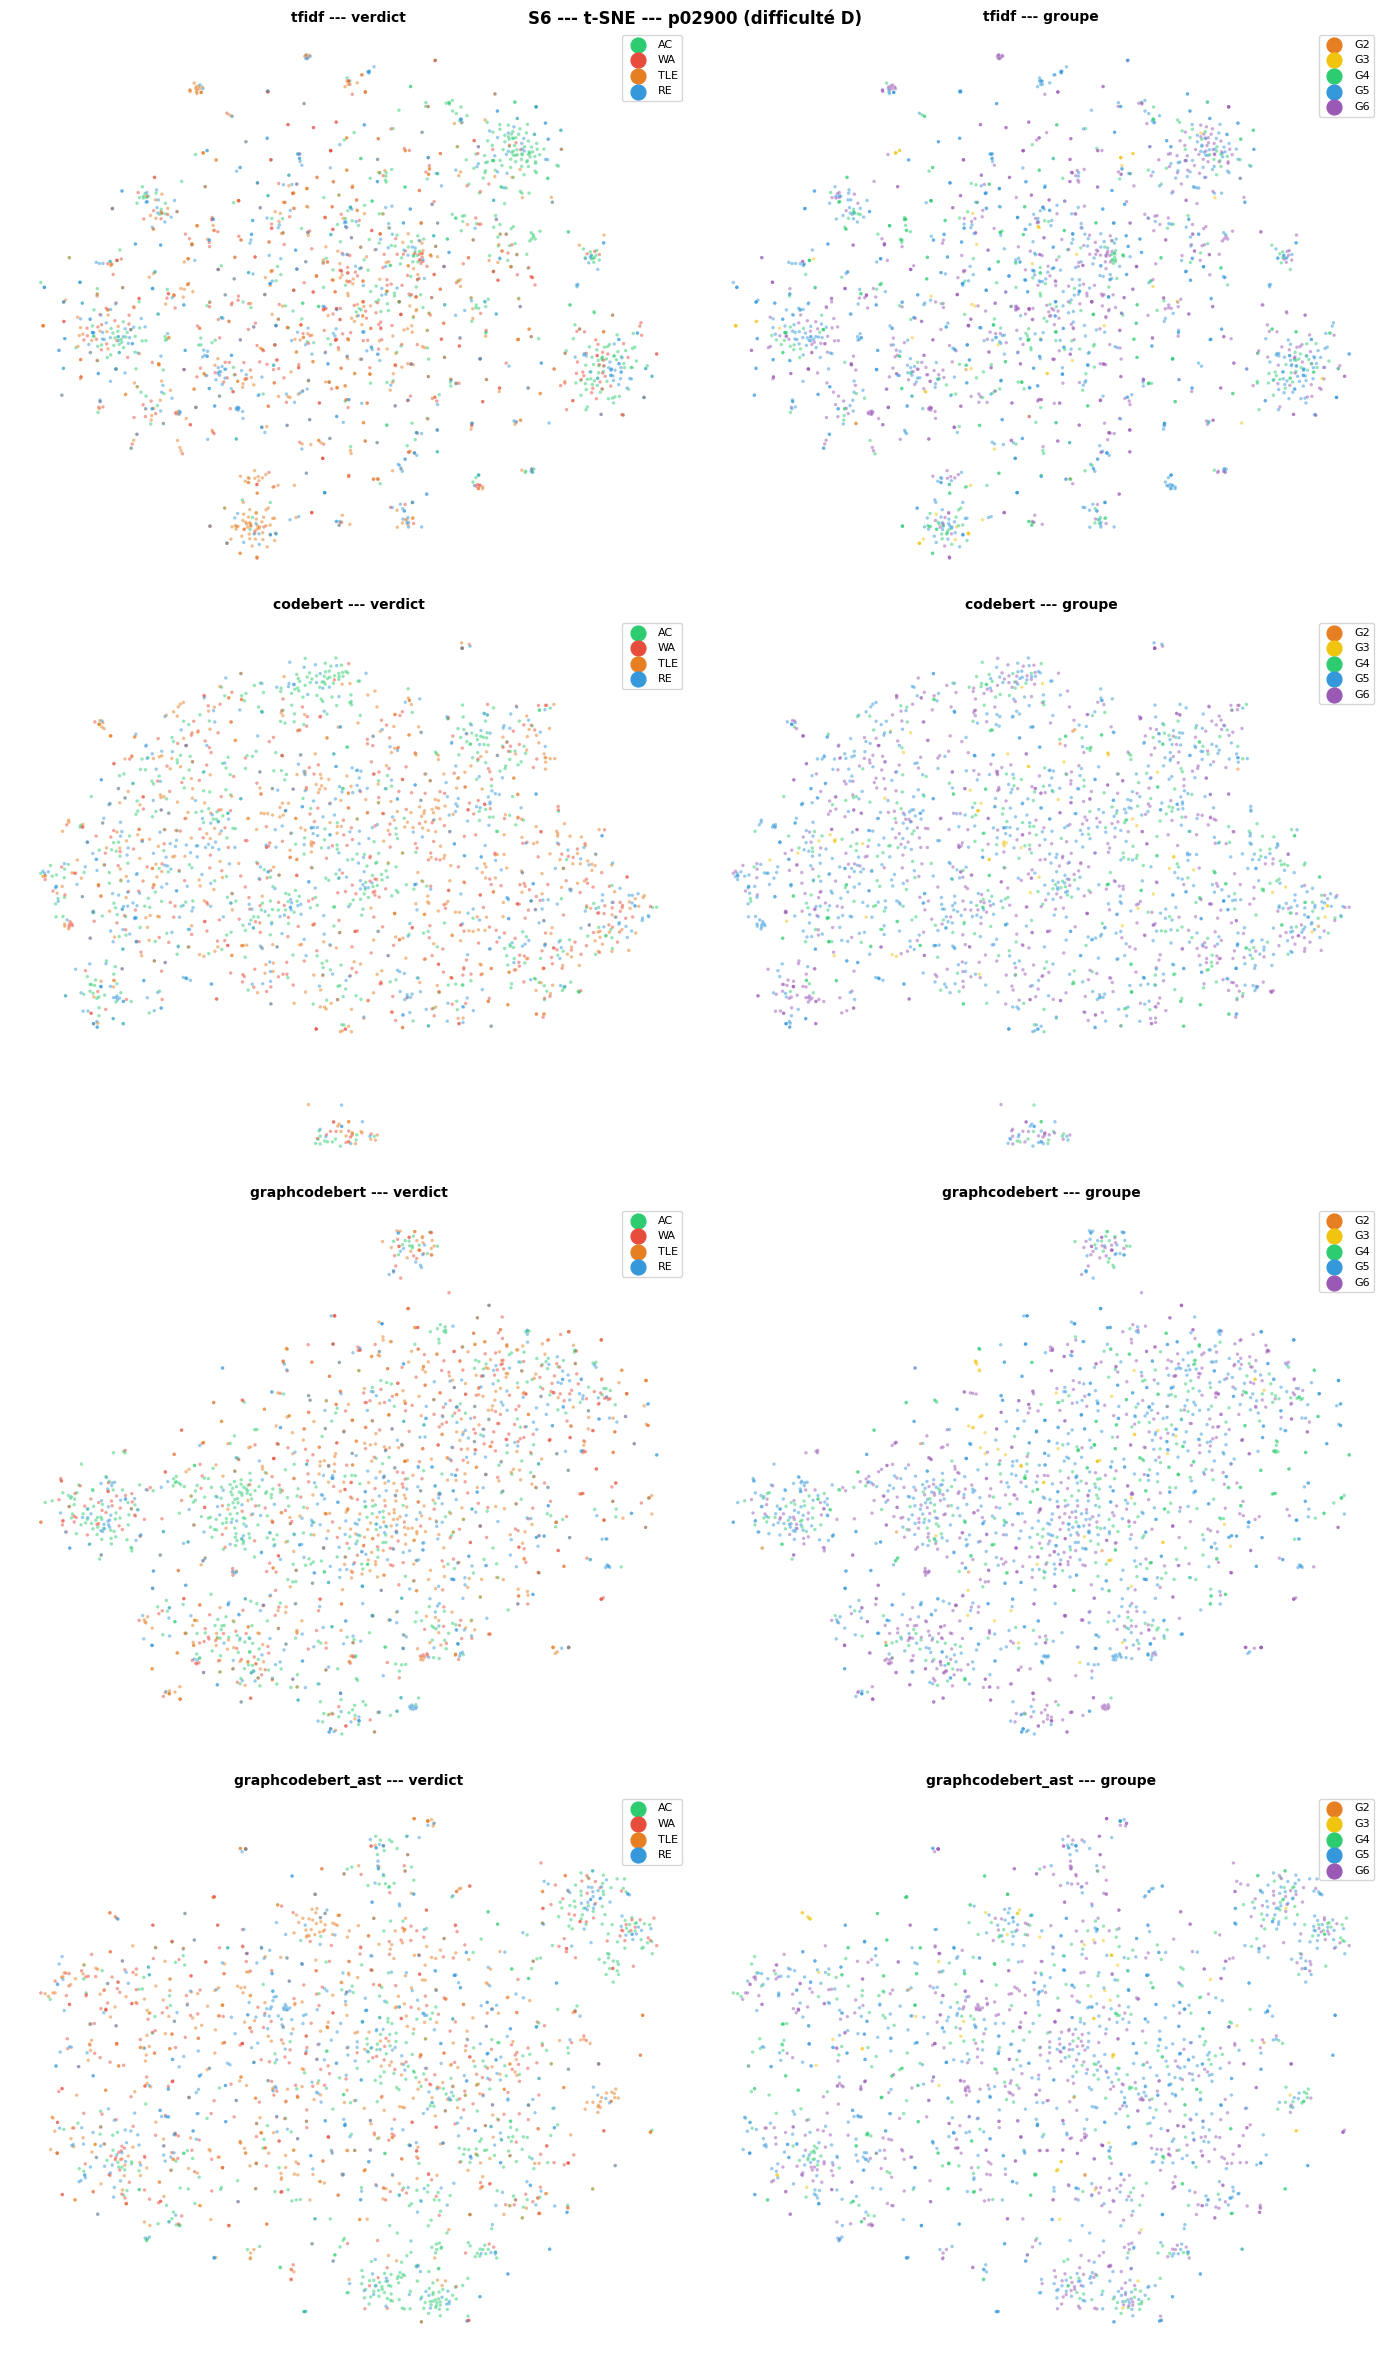

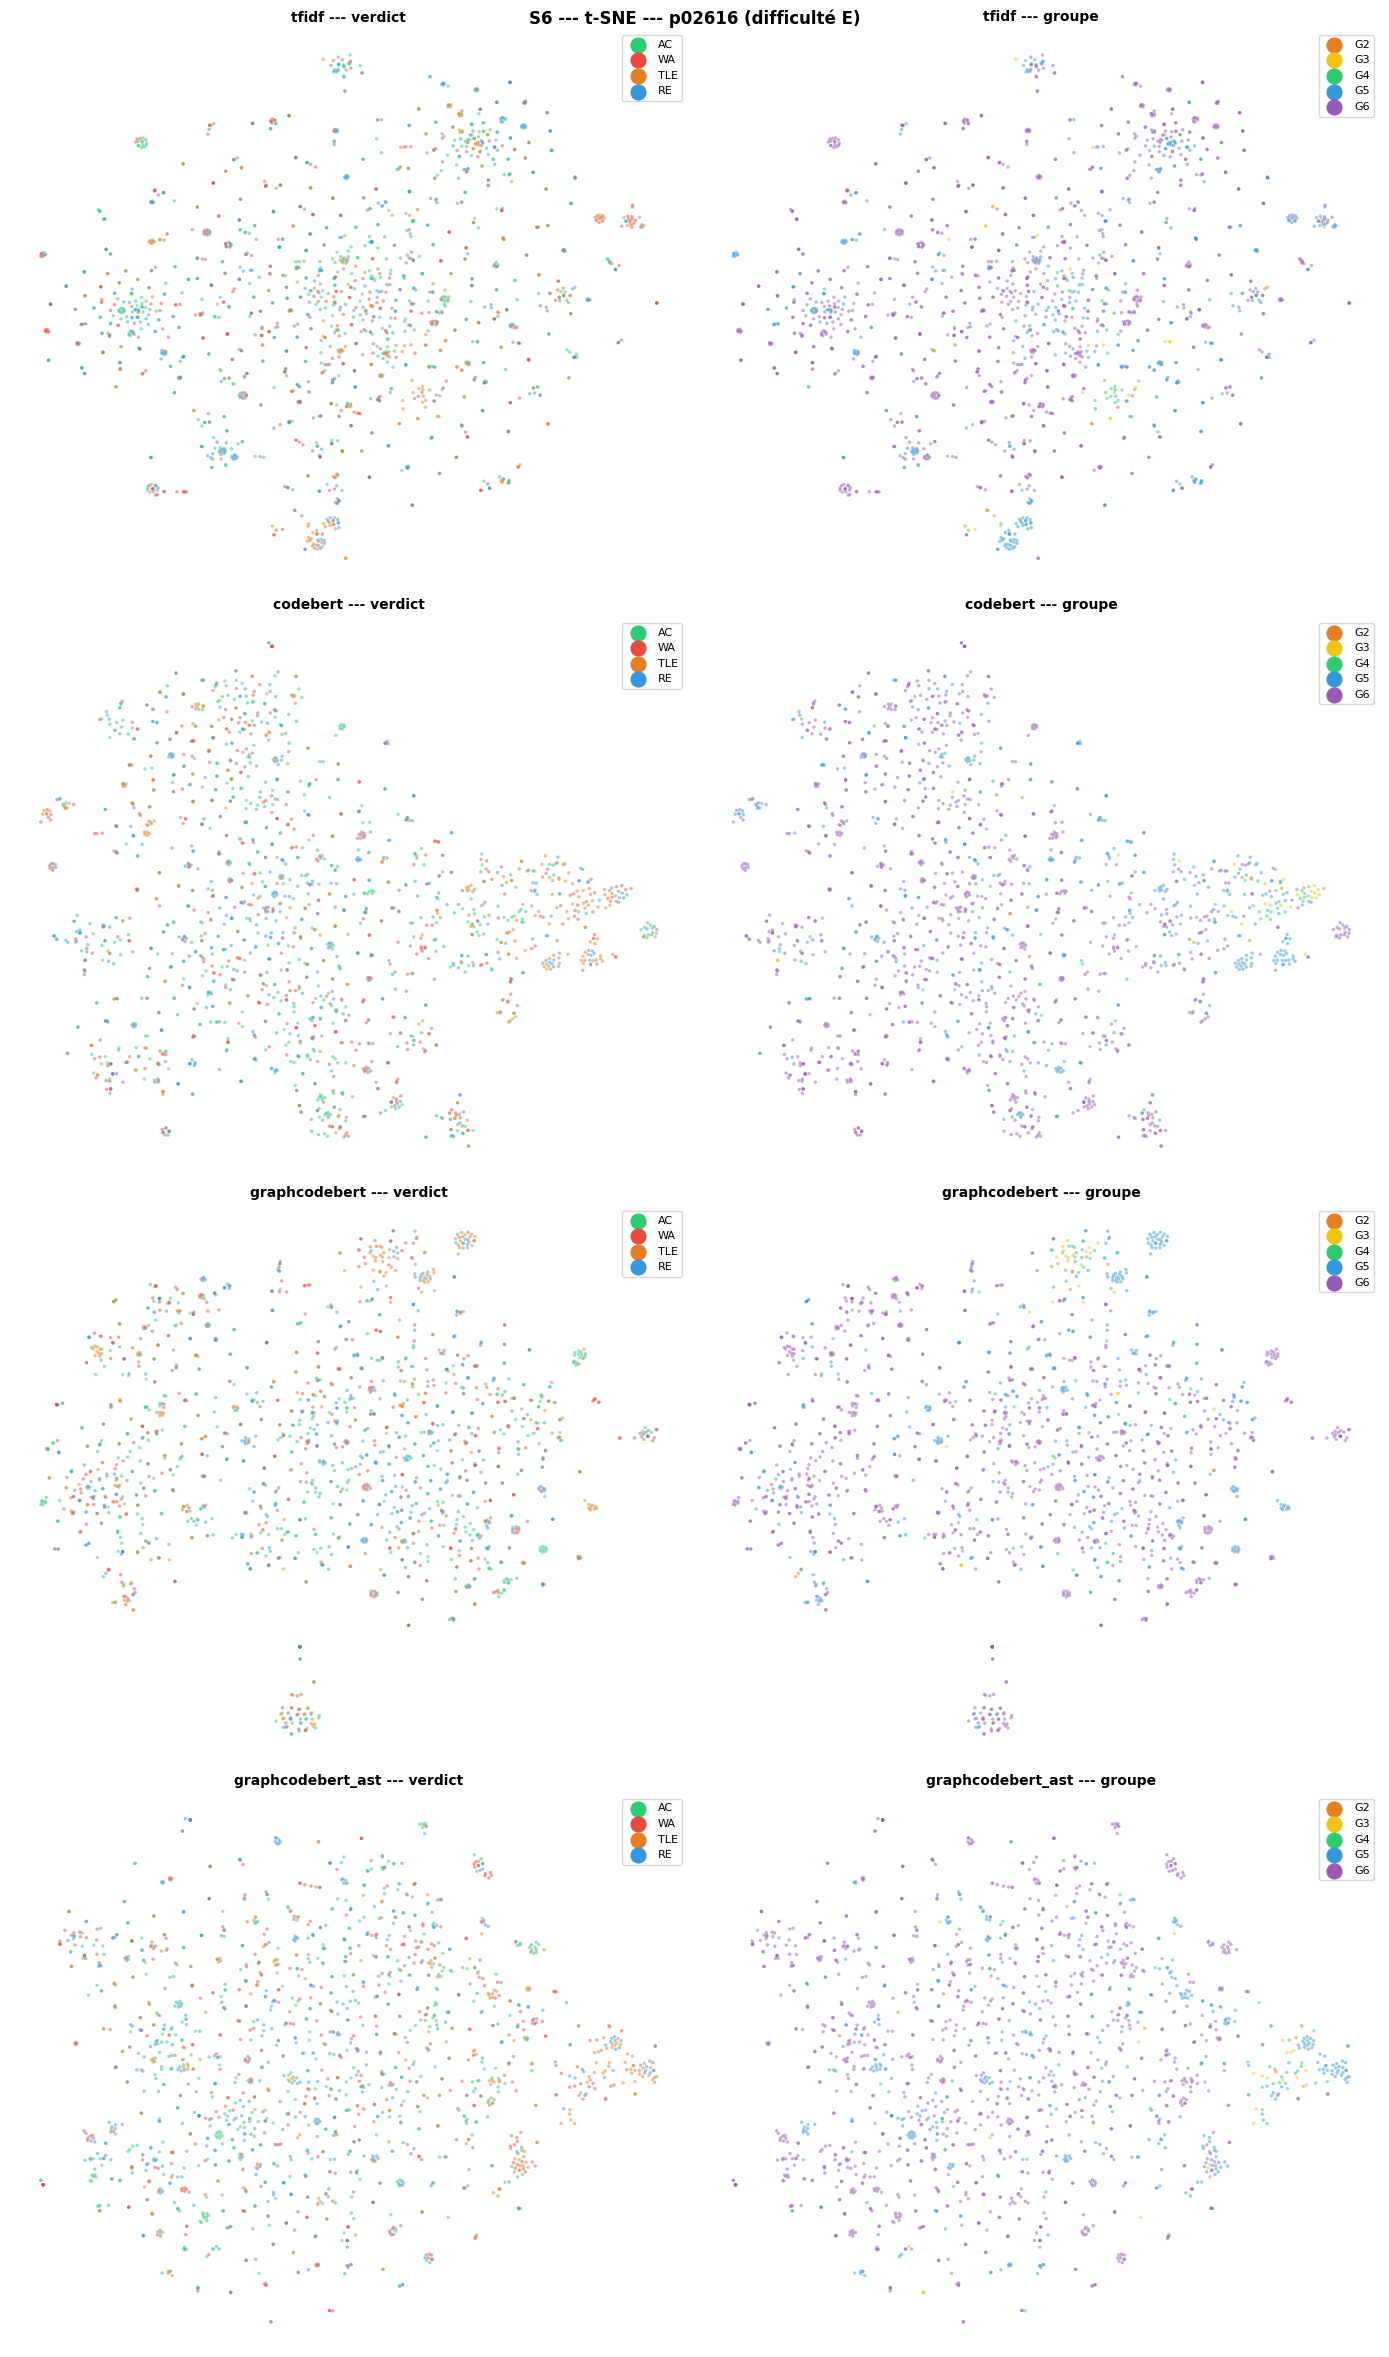

In [8]:
from sklearn.manifold import TSNE

if not best_per_diff:
    print("Δ(ast - naïf) indisponible --- section sautée (voir S5).")
else:
    for diff, pid in best_per_diff.items():
        fig, axes = plt.subplots(len(methods_present), len(TARGET_LABELS),
                                 figsize=(7 * len(TARGET_LABELS), 6 * len(methods_present)))
        axes = np.atleast_2d(axes)
        if axes.shape != (len(methods_present), len(TARGET_LABELS)):
            axes = axes.reshape(len(methods_present), len(TARGET_LABELS))

        for row_i, m in enumerate(methods_present):
            meta = df_meta_4[m]
            idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
            sub_emb = embeddings_4[m][idx]
            sub_meta = meta[idx]

            tsne = TSNE(n_components=2, random_state=42, metric='cosine', init='pca')
            proj = tsne.fit_transform(sub_emb)

            for col_i, label in enumerate(TARGET_LABELS):
                ax = axes[row_i, col_i]
                colors_map = STATUS_COLORS if label == 'status_code' else GROUP_COLORS
                order = STATUSES_ORDER if label == 'status_code' else GROUPS_ORDER
                vals = sub_meta[label].to_list()
                ax.scatter(proj[:, 0], proj[:, 1],
                          c=[colors_map.get(v, '#aaaaaa') for v in vals],
                          s=6, alpha=0.5, linewidths=0)
                for v in order:
                    if v in vals:
                        ax.scatter([], [], c=colors_map[v], s=35, label=v)
                ax.legend(fontsize=8, markerscale=1.8, framealpha=0.8)
                ax.set_title(f'{m.replace("_python_multi12", "")} --- {LABEL_NAMES[label]}',
                            fontsize=10, fontweight='bold')
                ax.axis('off')

        plt.suptitle(f'S6 --- t-SNE --- {pid} (difficulté {diff})', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

## S7 --- Synthèse
### S7 --- Synthesis

**Résultat, plus faible et plus mitigé qu'attendu --- et un correctif qui n'aide
qu'à moitié.** Δ(GraphCodeBERT_AST − GraphCodeBERT naïf) était initialement
mesuré avec un budget `DATA_FLOW_LENGTH=64` mal calibré : sur un échantillon
réel de 3000 soumissions, **36,8% avaient un graphe DFG brut de plus de 64
nœuds**, donc tronqué avant même d'atteindre le modèle --- contre seulement
7,1% de troncature côté code (`CODE_LENGTH=448`, largement surdimensionné en
comparaison). Passer à `CODE_LENGTH=384 / DATA_FLOW_LENGTH=128` (même budget
total de 512, le plafond réel du modèle) ramène la troncature du graphe à
9,8%, en échange d'une troncature code à 11,1% --- un compromis équilibré,
choisi en simulant plusieurs découpages sur cet échantillon plutôt qu'au
jugé. Un signe indépendant que ce n'était pas juste une hypothèse en l'air :
les soumissions TLE ont des graphes mesurablement plus gros que AC/WA/RE
(moyenne 82,5 nœuds contre ~63--66) --- donc de la structure liée au verdict
existe bel et bien, et la troncature la coupait plus souvent pile pour ces
cas-là.

Après régénération du corpus complet avec ce nouveau découpage :

| | Ancien (448/64) | Nouveau (384/128) |
|---|---|---|
| Δ ast-naïf, verdict | +0,016 (gagne 8/12) | +0,016 (gagne **10/12**) |
| Δ ast-naïf, groupe | −0,011 (gagne 3/12) | −0,011 (gagne 3/12, inchangé) |

La moyenne du delta verdict ne bouge pas, mais devient **plus régulière**
(10/12 problèmes plutôt que 8/12) --- la troncature expliquait donc une partie
du bruit, sans être toute l'histoire. Le groupe de compétence, lui, n'a
strictement pas changé : cohérent avec le fait que le lien structure/verdict
trouvé (via les graphes plus gros des soumissions TLE) n'a pas d'équivalent
évident pour prédire le niveau du programmeur --- pas surprenant que réparer
la troncature n'y change rien.

**La piste la plus solide reste ailleurs : la sonde supervisée.** Une
régression logistique entraînée directement sur les embeddings déjà
sauvegardés (validation croisée, pas le lift k-NN) montre que
`graphcodebert_ast` est en fait la **meilleure méthode des 4 sur le verdict**
(0,278 au-dessus du hasard, contre 0,244 pour le naïf, 0,248 CodeBERT, 0,211
TF-IDF) et bat aussi le naïf sur le groupe (0,094 contre 0,082) --- Δ(ast−naïf)
**positif sur les deux dimensions** sous cette lecture (+0,034 verdict,
+0,011 groupe), alors que le lift k-NN reste négatif sur le groupe. Ça
suggère que l'information est bien là dans l'embedding --- plus que dans le
naïf --- mais que la proximité brute en cosinus (ce que mesure le lift k-NN)
n'est pas la meilleure fenêtre pour la voir. Détail complet en S8, juste après
cette synthèse.

**Vu contre TF-IDF** : Δ(AST − TF-IDF) = +0,044 (verdict) et −0,004 (groupe)
--- contre Δ(naïf − TF-IDF) = +0,028 (verdict) et +0,008 (groupe) mesuré en
NB12. Construire le vrai graphe ajoute donc bien quelque chose de réel sur le
verdict par rapport au signal résiduel naïf ; sur le groupe, il fait toujours
un peu moins bien que ne rien construire du tout.

**Implication pour RQ2.** Le mécanisme de graphe, avec un budget correctement
calibré, améliore la *régularité* du gain sur le verdict sans en augmenter
l'ampleur moyenne, et n'apporte toujours rien sur le groupe de compétence.
La piste la plus prometteuse pour aller plus loin n'est pas d'ajuster encore
le budget de troncature, mais de changer la façon de lire l'information déjà
présente dans l'embedding --- la sonde supervisée le montre plus nettement
que le lift k-NN ne pourra jamais le faire par construction.

---

**A weaker, more mixed result than expected --- and a fix that only half
helps.** Δ(GraphCodeBERT_AST − GraphCodeBERT naive) was initially measured
with a miscalibrated `DATA_FLOW_LENGTH=64` budget: on a real 3000-submission
sample, **36.8% had a raw DFG graph with more than 64 nodes**, truncated
before ever reaching the model --- versus only 7.1% truncation on the code
side (`CODE_LENGTH=448`, comparatively oversized). Switching to
`CODE_LENGTH=384 / DATA_FLOW_LENGTH=128` (same 512 total budget, the model's
actual ceiling) brings graph truncation down to 9.8%, in exchange for 11.1%
code truncation --- a balanced tradeoff, chosen by simulating several splits
on that sample rather than guessing. An independent sign this wasn't just a
hunch: TLE submissions have measurably bigger graphs than AC/WA/RE (mean 82.5
nodes vs ~63--66) --- so verdict-linked structure genuinely exists, and
truncation was cutting it off disproportionately for exactly those cases.

After regenerating the full corpus with the new split:

| | Old (448/64) | New (384/128) |
|---|---|---|
| Δ ast-naive, verdict | +0.016 (wins 8/12) | +0.016 (wins **10/12**) |
| Δ ast-naive, group | −0.011 (wins 3/12) | −0.011 (wins 3/12, unchanged) |

The average verdict delta doesn't move, but becomes **more consistent** (10/12
problems rather than 8/12) --- truncation did explain part of the noise,
without being the whole story. Proficiency group didn't change at all:
consistent with the structure/verdict link found (via TLE submissions' bigger
graphs) having no obvious equivalent for predicting programmer skill --- not
surprising that fixing truncation leaves it untouched.

**The stronger lead is elsewhere: the supervised probe.** A logistic
regression trained directly on the already-saved embeddings (cross-validated,
not k-NN lift) shows `graphcodebert_ast` is actually the **best of the 4
methods on verdict** (0.278 above chance, vs 0.244 naive, 0.248 CodeBERT,
0.211 TF-IDF) and also beats naive on group (0.094 vs 0.082) --- Δ(ast-naive)
**positive on both dimensions** under this lens (+0.034 verdict, +0.011
group), while k-NN lift stays negative on group. This suggests the
information really is in the embedding --- more so than in the naive one ---
but that raw cosine proximity (what k-NN lift measures) isn't the best window
to see it through. Full detail in S8, right after this synthesis.

**Against TF-IDF**: Δ(AST − TF-IDF) = +0.044 (verdict) and −0.004 (group) ---
versus Δ(naive − TF-IDF) = +0.028 (verdict) and +0.008 (group) measured in
NB12. Building the real graph does add something genuine on verdict beyond
the naive residual signal; on group, it still does slightly worse than
building nothing at all.

**Implication for RQ2.** The graph mechanism, with a properly calibrated
budget, improves the *consistency* of the verdict gain without increasing its
average size, and still contributes nothing on proficiency group. The most
promising next lever isn't further truncation tuning -- it's changing how the
already-present information in the embedding gets read out. The supervised
probe already shows this more clearly than k-NN lift ever structurally can.

## S8 --- Nouvel essai : une sonde supervisée sous-estime-t-elle le lift k-NN ?
### S8 --- Second Attempt: Is k-NN Lift Underselling the Signal?

S7 conclut sur un mécanisme de graphe qui n'apporte, au mieux, qu'un gain
modeste et inégal. Avant d'en rester là, une dernière chose à vérifier :
est-ce le mécanisme lui-même qui est faible, ou seulement la façon dont S3 le
mesure ?

Le lift k-NN pose une question précise : les plus proches voisins d'un point
partagent-ils son étiquette plus souvent que le hasard ? C'est une question
purement locale et non supervisée --- elle ne regarde jamais les étiquettes
pendant le calcul, seulement après coup pour vérifier.

Une question différente, complémentaire : combien d'information sur
l'étiquette est récupérable dans l'embedding, tout court --- en entraînant une
règle de décision dessus plutôt qu'en espérant qu'elle émerge de la
proximité brute ? On entraîne une régression logistique (validation croisée
stratifiée, jamais testée sur ses propres données d'entraînement) par
problème et par méthode, et on compare sa précision à une baseline "toujours
prédire la classe majoritaire".

Les deux questions peuvent diverger fortement : un espace peut ne montrer
aucune structure de voisinage nette (S3) tout en contenant une frontière de
décision linéaire bien réelle qu'une règle apprise sait retrouver.

---

S7 concludes with a graph mechanism that delivers, at best, a modest and
uneven gain. Before leaving it there, one last thing worth checking: is it
the mechanism itself that's weak, or just how S3 measures it?

k-NN lift asks a precise question: do a point's nearest neighbors share its
label more often than chance? That's a purely local, unsupervised question
--- it never looks at labels during the computation, only afterward to check.

A different, complementary question: how much information about the label is
recoverable from the embedding at all --- by training a decision rule on it,
rather than hoping it emerges from raw proximity? We train a logistic
regression (stratified cross-validation, never tested on its own training
data) per problem and per method, and compare its accuracy to an "always
predict the majority class" baseline.

The two questions can diverge sharply: a space can show no clean neighborhood
structure (S3) while still containing a real linear decision boundary that a
learned rule can find.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

s8_rows = []
for m in methods_present:
    emb, meta = embeddings_4[m], df_meta_4[m]

    for pid in pid_list:
        idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
        if len(idx) < 50:
            continue
        sub_emb = emb[idx]

        for label in TARGET_LABELS:
            y = meta[label].to_numpy()[idx]
            classes, counts = np.unique(y, return_counts=True)
            if len(classes) < 2 or counts.min() < 5:
                continue  # pas assez d'exemples de la classe minoritaire pour la CV

            n_splits = min(5, counts.min())
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

            clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
            probe_acc = cross_val_score(clf, sub_emb, y, cv=skf, scoring='accuracy').mean()

            dummy = DummyClassifier(strategy='most_frequent')
            dummy_acc = cross_val_score(dummy, sub_emb, y, cv=skf, scoring='accuracy').mean()

            s8_rows.append({
                'method': m, 'problem_id': pid, 'label': label,
                'probe_acc': probe_acc, 'dummy_acc': dummy_acc,
                'probe_lift': probe_acc - dummy_acc,
            })

    print(f"{m} : sonde terminée")

df_s8 = pl.DataFrame(s8_rows)
piv_probe = df_s8.pivot(on='method', index=['problem_id', 'label'], values='probe_lift')
piv_probe = piv_probe.rename({m: m.replace('_python_multi12', '') for m in methods_present})

print("\nPrécision de la sonde au-dessus de la baseline majoritaire, moyenne par méthode x étiquette :")
short_cols = [c for c in piv_probe.columns if c not in ('problem_id', 'label')]
print(piv_probe.group_by('label').agg([pl.col(c).mean().alias(c) for c in short_cols]))

if 'graphcodebert_ast' in piv_probe.columns and 'graphcodebert' in piv_probe.columns:
    piv_probe = piv_probe.with_columns(
        (pl.col('graphcodebert_ast') - pl.col('graphcodebert')).alias('d_ast_naive_probe')
    )
    print("\nΔ(ast - naïf) sous la sonde, par étiquette :")
    print(piv_probe.group_by('label').agg(pl.col('d_ast_naive_probe').mean()))
else:
    print("\ngraphcodebert_ast non chargé --- pas de comparaison possible (voir S2).")

tfidf_python_multi12 : sonde terminée
codebert_python_multi12 : sonde terminée
graphcodebert_python_multi12 : sonde terminée
graphcodebert_ast_python_multi12 : sonde terminée

Précision de la sonde au-dessus de la baseline majoritaire, moyenne par méthode x étiquette :
shape: (2, 5)
┌───────────────────┬──────────┬──────────┬───────────────┬───────────────────┐
│ label             ┆ tfidf    ┆ codebert ┆ graphcodebert ┆ graphcodebert_ast │
│ ---               ┆ ---      ┆ ---      ┆ ---           ┆ ---               │
│ str               ┆ f64      ┆ f64      ┆ f64           ┆ f64               │
╞═══════════════════╪══════════╪══════════╪═══════════════╪═══════════════════╡
│ proficiency_group ┆ 0.119612 ┆ 0.085198 ┆ 0.082485      ┆ 0.095652          │
│ status_code       ┆ 0.211117 ┆ 0.247756 ┆ 0.243763      ┆ 0.280603          │
└───────────────────┴──────────┴──────────┴───────────────┴───────────────────┘

Δ(ast - naïf) sous la sonde, par étiquette :
shape: (2, 2)
┌───────────────

### Figure --- accuracy brute + baseline en repere
### Figure --- Raw Accuracy + Baseline as a Reference Line

Meme donnee que le tableau ci-dessus, lue autrement. Le tableau precedent
soustrait la baseline (`probe_lift = probe_acc - dummy_acc`) --- correct
methodologiquement, mais un chiffre deja soustrait se lit mal seul : il donne
l'impression trompeuse que le modele se trompe plus qu'il ne le fait vraiment.
Ici, la hauteur des barres est l'accuracy brute (facile a lire), et la ligne
pointillee est la baseline moyenne (deviner tout le temps le verdict
majoritaire) --- on voit direct que le modele bat la baseline sans calcul
mental. Moyenne sur les memes problemes que S8 (label `status_code`
uniquement -- prediction du verdict, pas du groupe).

---

Same data as the table above, read differently. The table above subtracts
the baseline (`probe_lift = probe_acc - dummy_acc`) --- methodologically
correct, but an already-subtracted number reads poorly on its own: it gives
the misleading impression the model is wrong more often than it really is.
Here, bar height is raw accuracy (easy to read), and the dashed line is the
average baseline (always guessing the majority verdict) --- you can see the
model beats the baseline without doing mental subtraction. Averaged over the
same problems as S8 (`status_code` label only --- verdict prediction, not
group).

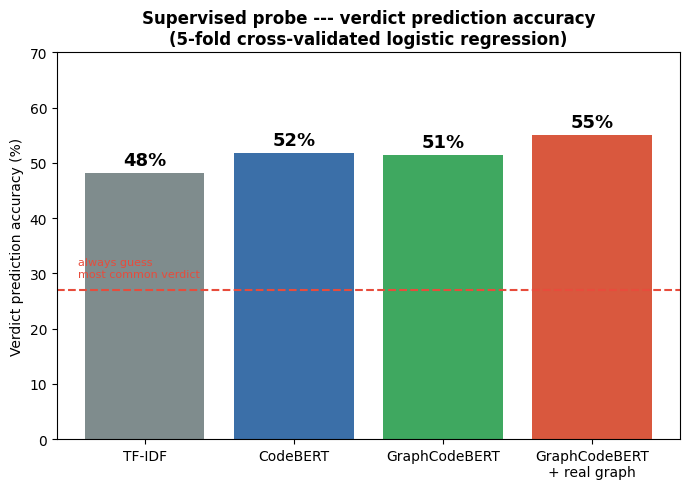

Baseline moyenne (classe majoritaire) : 27.0%
4 methodes, moyenne sur 10 problemes (sur 12 au total -- voir S8 pour les exclus)


In [10]:
df_status = df_s8.filter(pl.col('label') == 'status_code')
method_order = [m for m in methods_present if m in df_status['method'].unique().to_list()]

means = (
    df_status.group_by('method')
    .agg([pl.col('probe_acc').mean().alias('probe_acc'), pl.col('dummy_acc').mean().alias('dummy_acc')])
)
means_dict = {row['method']: (row['probe_acc'], row['dummy_acc']) for row in means.to_dicts()}

labels_disp = {
    'tfidf_python_multi12': 'TF-IDF',
    'codebert_python_multi12': 'CodeBERT',
    'graphcodebert_python_multi12': 'GraphCodeBERT',
    'graphcodebert_ast_python_multi12': 'GraphCodeBERT\n+ real graph',
}
bar_colors = ['#7f8c8d', '#3b6fa8', '#3fa860', '#d9583e']

xs   = [labels_disp.get(m, m) for m in method_order]
accs = [means_dict[m][0] for m in method_order]
avg_baseline = float(np.mean([means_dict[m][1] for m in method_order]))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(xs, [a * 100 for a in accs], color=bar_colors[:len(xs)])
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, a * 100 + 1.5, f"{a*100:.0f}%",
            ha='center', fontsize=13, fontweight='bold')

ax.axhline(avg_baseline * 100, color='#e74c3c', linestyle='--', linewidth=1.5)
ax.text(-0.45, avg_baseline * 100 + 2, "always guess\nmost common verdict",
        color='#e74c3c', fontsize=8, ha='left', va='bottom')

ax.set_ylabel('Verdict prediction accuracy (%)')
ax.set_title('Supervised probe --- verdict prediction accuracy\n(5-fold cross-validated logistic regression)',
              fontsize=12, fontweight='bold')
ax.set_ylim(0, max(accs) * 100 + 15)
plt.tight_layout()
plt.show()

n_problems = df_status['problem_id'].n_unique()
print(f"Baseline moyenne (classe majoritaire) : {avg_baseline*100:.1f}%")
print(f"{len(method_order)} methodes, moyenne sur {n_problems} problemes "
      f"(sur {len(pid_list)} au total -- voir S8 pour les exclus)")

## S9 --- Lecture par moyenne plutôt que par CLS seul
### S9 --- Mean Readout Instead of CLS Alone

Toujours `graphcodebert_ast`, toujours le même mécanisme de graphe --- seule
la dernière étape change. Jusqu'ici, on ne gardait que la position CLS en
sortie du modèle (un résumé censé représenter tout le reste). `pooling="mean"`
(nouveau dans `embed_graphcodebert_ast()`) fait la moyenne de toutes les
positions de vrais tokens de code à la place, en excluant CLS/SEP et les
nœuds de graphe. Aucune des deux n'a été entraînée pour cette tâche
précise (voir l'historique du pooler manquant) --- rien ne garantit que CLS
soit le meilleur résumé possible, la moyenne est une autre hypothèse
raisonnable.

Corpus régénéré séparément (`GCB_POOLING=mean`, tag `_mean`, mêmes 12
problèmes, même tirage) --- on vérifie explicitement que les deux corpus
contiennent bien les mêmes soumissions dans le même ordre avant de comparer,
plutôt que de le supposer.

---

Still `graphcodebert_ast`, still the same graph mechanism --- only the last
step changes. Until now, only the CLS position was kept from the model's
output (a summary meant to represent everything else). `pooling="mean"` (new
in `embed_graphcodebert_ast()`) averages all real code-token positions
instead, excluding CLS/SEP and the graph nodes. Neither was ever trained for
this specific task (see the missing-pooler story) --- there's no guarantee
CLS is the best possible summary; the average is another reasonable
hypothesis.

Corpus regenerated separately (`GCB_POOLING=mean`, `_mean` tag, same 12
problems, same draw) --- we explicitly verify both corpora contain the same
submissions in the same order before comparing, rather than assuming it.

In [11]:
mean_emb_path  = EMBEDDINGS_DIR / "embeddings_graphcodebert_ast_python_multi12_mean.npy"
mean_meta_path = EMBEDDINGS_DIR / "metadata_graphcodebert_ast_python_multi12_mean.csv"

if not mean_emb_path.exists():
    print("Corpus mean-pooling introuvable --- GCB_POOLING=mean python src/embedding.py graphcodebert_ast ...")
else:
    emb_mean  = np.load(mean_emb_path)
    meta_mean = pl.read_csv(mean_meta_path)
    emb_cls   = embeddings_4["graphcodebert_ast_python_multi12"]
    meta_cls  = df_meta_4["graphcodebert_ast_python_multi12"]

    assert (meta_mean["submission_id"].to_numpy() == meta_cls["submission_id"].to_numpy()).all(), \
        "les deux corpus n'ont pas les mêmes soumissions dans le même ordre -- comparaison invalide"
    print(f"Alignement vérifié : {meta_cls.height} soumissions identiques, même ordre.")

    s10_rows = []
    for pooling_name, emb in [("cls", emb_cls), ("mean", emb_mean)]:
        for pid in pid_list:
            idx = np.where((meta_cls['problem_id'] == pid).to_numpy())[0]
            if len(idx) < 50:
                continue
            for label in TARGET_LABELS:
                y = meta_cls[label].to_numpy()[idx]
                classes, counts = np.unique(y, return_counts=True)
                if len(classes) < 2 or counts.min() < 5:
                    continue
                n_splits = min(5, counts.min())
                skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
                clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
                dummy = DummyClassifier(strategy='most_frequent')
                acc = cross_val_score(clf, emb[idx], y, cv=skf, scoring='accuracy').mean()
                dummy_acc = cross_val_score(dummy, emb[idx], y, cv=skf, scoring='accuracy').mean()
                s10_rows.append({'pooling': pooling_name, 'problem_id': pid, 'label': label,
                                  'lift': acc - dummy_acc})
        print(f"pooling={pooling_name} : sonde terminée")

    df_s10 = pl.DataFrame(s10_rows)
    piv_pool = df_s10.pivot(on='pooling', index=['problem_id', 'label'], values='lift')
    piv_pool = piv_pool.with_columns((pl.col('mean') - pl.col('cls')).alias('d_mean_cls'))

    print("\nLift moyen par méthode de lecture (cls vs mean), par étiquette :")
    print(piv_pool.group_by('label').agg([
        pl.col('cls').mean(), pl.col('mean').mean(), pl.col('d_mean_cls').mean(),
    ]))

Alignement vérifié : 21773 soumissions identiques, même ordre.
pooling=cls : sonde terminée
pooling=mean : sonde terminée

Lift moyen par méthode de lecture (cls vs mean), par étiquette :
shape: (2, 4)
┌───────────────────┬──────────┬──────────┬────────────┐
│ label             ┆ cls      ┆ mean     ┆ d_mean_cls │
│ ---               ┆ ---      ┆ ---      ┆ ---        │
│ str               ┆ f64      ┆ f64      ┆ f64        │
╞═══════════════════╪══════════╪══════════╪════════════╡
│ proficiency_group ┆ 0.095652 ┆ 0.09759  ┆ 0.001938   │
│ status_code       ┆ 0.280603 ┆ 0.314812 ┆ 0.034209   │
└───────────────────┴──────────┴──────────┴────────────┘
